<a href="https://colab.research.google.com/github/FarhanKO/Disease-Risk-Prediction/blob/main/Research/Kidney/Kidney_Disease_Tabular.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chronic Kidney Disease (CKD) Prediction and Analysis

## Project Overview
This project develops a robust, interpretable, and clinically actionable machine learning pipeline for predicting Chronic Kidney Disease (CKD). By leveraging demographic, lab, and clinical data, this notebook demonstrates an end-to-end data science workflow designed for safe real-world medical screening.

## Key Highlights
* **Advanced Preprocessing & Feature Engineering:** Handles class imbalance and missing data using SMOTE and KNN imputation, alongside custom clinical feature combinations (e.g., BUN-to-Creatinine ratio, Calcium-Phosphorus product).
* **Supervised Classification:** Evaluates multiple machine learning algorithms (including RAPIDS cuML accelerated models), culminating in a highly sensitive LightGBM model prioritized for high Recall to minimize missed diagnoses (False Negatives).
* **Model Calibration & Optimization:** Enhances probability reliability using Isotonic calibration, validates stability with bootstrapped confidence intervals, and applies cost-based threshold optimization for clinical safety.
* **Unsupervised Learning & Anomaly Detection:** Applies dimensionality reduction (PCA, t-SNE) and clustering to uncover natural patient groupings. Uses an ensemble of anomaly detectors (Isolation Forest, Autoencoders, etc.) to flag extreme clinical outliers.
* **Explainable AI (XAI) Cascade:** Integrates SHAP values into a two-stage clinical cascade architecture, ensuring every prediction is safe and accompanied by a transparent, interpretable clinical explanation.

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline # Kept for standard preprocessing
from imblearn.pipeline import Pipeline as ImbPipeline # Required for SMOTE integration
from imblearn.over_sampling import SMOTE # Synthetic minority over-sampling
from xgboost import XGBClassifier # Advanced Gradient Boosting

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, precision_recall_curve, roc_curve, auc
)

from sklearn.preprocessing import FunctionTransformer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

# Database Load & Analysis

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_folder = "/content/drive/MyDrive/AI Projects/Kidney Disease/"
csv_filename = "CKD_NHANES.csv"

if os.path.exists(data_folder):
    print(f"Files located in '{data_folder}':")
    print(os.listdir(data_folder))
    print("=" * 60)
else:
    print(f"⚠️ Directory not found: {data_folder}")

try:
    kidney_data = pd.read_csv(os.path.join(data_folder, csv_filename))

    print("\n DATASET PREVIEW (First 5 Rows):")
    display(kidney_data.head())

    print("\n DATASET STRUCTURE:")
    kidney_data.info()

    print("\n STATISTICAL SUMMARY (Transposed):")
    display(kidney_data.describe().T)

except FileNotFoundError:
    print(f"\n❌ ERROR: Could not find '{csv_filename}'.")
    print("Please copy the exact file name from the 📁 Files list above and update 'csv_filename'.")


Files located in '/content/drive/MyDrive/AI Projects/Kidney Disease/':
['CKD_NHANES.csv', 'Kidney Disease.ipynb']

 DATASET PREVIEW (First 5 Rows):


,participant_id,age,gender,ethnicity,education_level,poverty_income_ratio,bmi,weight_kg,height_cm,bp_systolic,...,urine_albumin,albumin_creatinine_ratio,diabetes_diagnosed,insulin_use,diabetes_pills,ever_smoked,current_smoker,egfr,ckd_stage,ckd_present
0,130378.0,43.0,Male,Non-Hispanic Asian,5.0,5.00,27.0,86.9,179.5,135.0,...,23.12,17.00,2.0,NaN,NaN,1.0,3.0,112.61,No CKD,0
1,130379.0,66.0,Male,Non-Hispanic White,5.0,5.00,33.5,101.8,174.2,121.0,...,4.25,6.64,2.0,NaN,NaN,1.0,3.0,97.98,No CKD,0
2,130380.0,44.0,Female,Other Hispanic,3.0,1.41,29.7,69.4,152.9,111.0,...,12.43,7.92,1.0,2.0,1.0,2.0,NaN,111.69,No CKD,0
3,130381.0,5.0,Female,Other/Multiracial,NaN,1.53,23.8,34.3,120.1,NaN,...,16.12,7.75,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1
4,130382.0,2.0,Male,Non-Hispanic White,NaN,3.60,NaN,13.6,NaN,NaN,...,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,Unknown,1



 DATASET STRUCTURE:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   participant_id            11933 non-null  float64
 1   age                       11933 non-null  float64
 2   gender                    11933 non-null  object 
 3   ethnicity                 11933 non-null  object 
 4   education_level           7794 non-null   float64
 5   poverty_income_ratio      9892 non-null   float64
 6   bmi                       8471 non-null   float64
 7   weight_kg                 8754 non-null   float64
 8   height_cm                 8499 non-null   float64
 9   bp_systolic               7517 non-null   float64
 10  bp_diastolic              7517 non-null   float64
 11  serum_creatinine          6326 non-null   float64
 12  blood_urea_nitrogen       6326 non-null   float64
 13  albumin_serum             6366 non-null 

,count,mean,std,min,25%,50%,75%,max
participant_id,11933.0,136344.000000,3444.904716,1.303780e+05,133361.0000,136344.00,139327.00,142310.00
age,11933.0,38.317858,25.601990,5.397605e-79,13.0000,37.00,62.00,80.00
education_level,7794.0,3.804978,1.153750,1.000000e+00,3.0000,4.00,5.00,9.00
poverty_income_ratio,9892.0,2.708174,1.670119,5.397605e-79,1.1800,2.50,4.50,5.00
bmi,8471.0,27.246665,8.137781,1.110000e+01,21.6000,26.40,31.70,74.80
weight_kg,8754.0,70.549037,30.389021,2.700000e+00,54.2000,71.70,89.10,248.20
height_cm,8499.0,159.664549,19.864943,7.910000e+01,154.4000,163.60,172.10,200.70
bp_systolic,7517.0,119.288546,18.561052,6.100000e+01,106.0000,117.00,130.00,232.00
bp_diastolic,7517.0,72.748038,11.895572,3.300000e+01,64.0000,72.00,80.00,142.00
serum_creatinine,6326.0,0.872828,0.385498,3.300000e-01,0.7000,0.83,0.98,15.17


### Dataset Distribution

In [ ]:
print(kidney_data['ckd_present'].value_counts(dropna=False))
kidney_data = kidney_data.dropna(subset=['ckd_present'])   # Remove Row that has no num

ckd_present
1    8341
0    3592
Name: count, dtype: int64


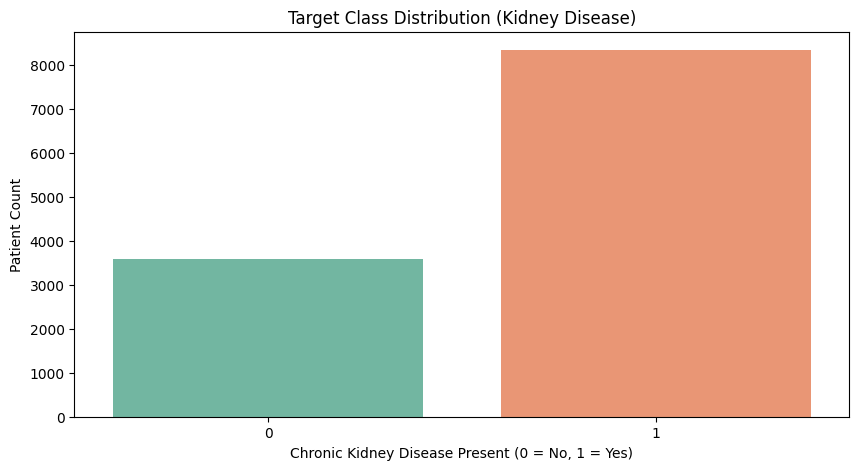

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x="ckd_present", data=kidney_data, palette="Set2")
plt.xlabel("Chronic Kidney Disease Present (0 = No, 1 = Yes)")
plt.ylabel("Patient Count")
plt.title("Target Class Distribution (Kidney Disease)")
plt.show()

### Correlation Analysis

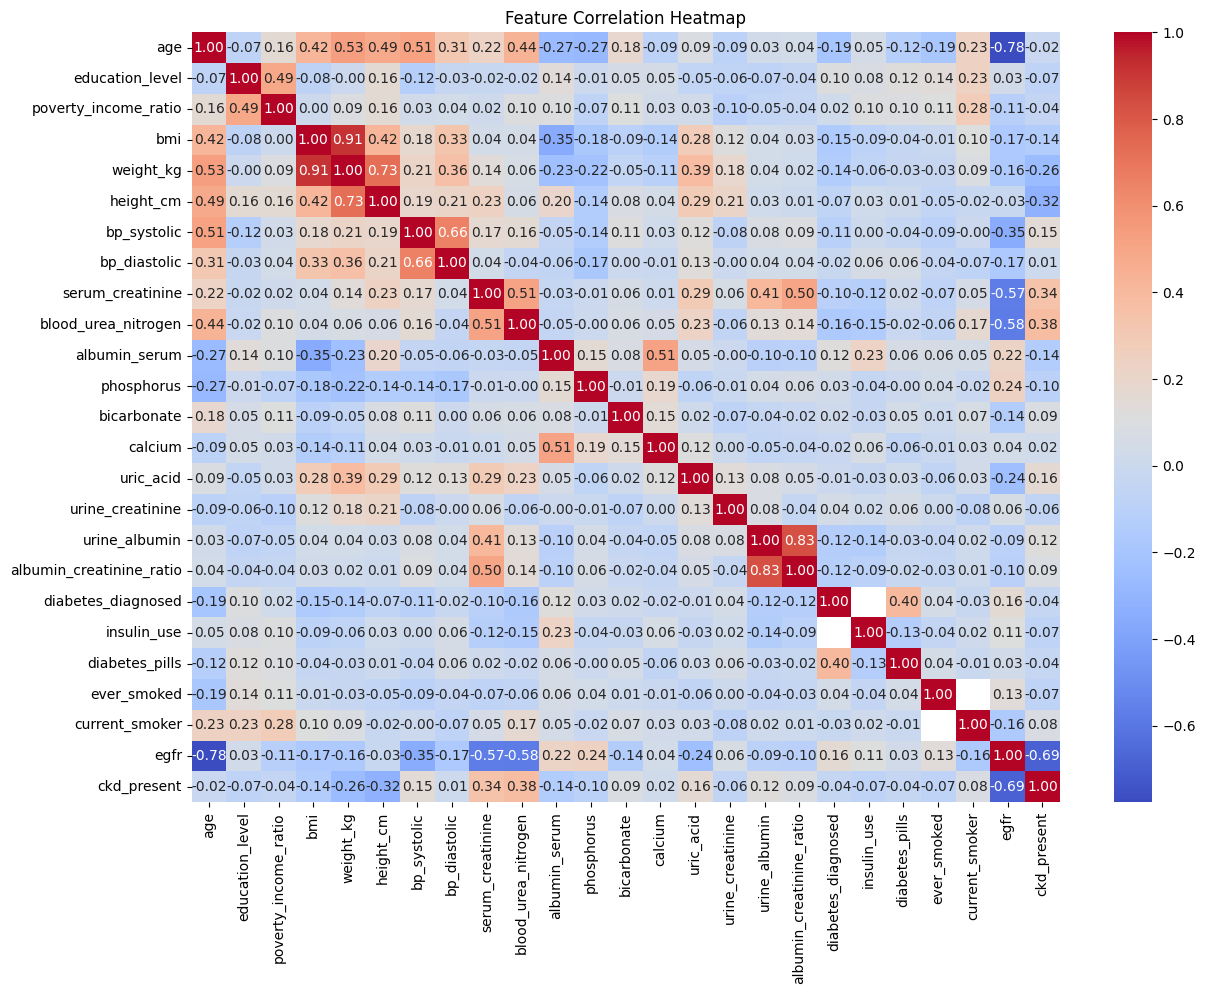

In [ ]:
# Drop the 'id' column and save the change back to kidney_data
kidney_data = kidney_data.drop(columns=['participant_id'], errors='ignore')

plt.figure(figsize=(14, 10))
sns.heatmap(kidney_data.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


The heatmap reveals a strong negative correlation between eGFR (estimated glomerular filtration rate) and kidney damage indicators like serum creatinine and blood urea nitrogen. Additionally, the target variable (`ckd_present`) shows a strong positive correlation with age and these damage indicators, while being inversely related to eGFR. This confirms that reduced kidney filtration rates and elevated waste products in the blood are the primary predictors of chronic kidney disease.

In [ ]:
threshold = 0.85
corr_matrix = kidney_data.corr(numeric_only=True).abs()

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

features_to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)]

print(f"Features highly correlated (>{threshold}) will be dropped: {features_to_drop}")
kidney_data = kidney_data.drop(columns=features_to_drop)
print("\nRemaining columns in the dataset:")
print(kidney_data.columns.tolist())


Features highly correlated (>0.85) will be dropped: ['weight_kg']

Remaining columns in the dataset:
['age', 'gender', 'ethnicity', 'education_level', 'poverty_income_ratio', 'bmi', 'height_cm', 'bp_systolic', 'bp_diastolic', 'serum_creatinine', 'blood_urea_nitrogen', 'albumin_serum', 'phosphorus', 'bicarbonate', 'calcium', 'uric_acid', 'urine_creatinine', 'urine_albumin', 'albumin_creatinine_ratio', 'diabetes_diagnosed', 'insulin_use', 'diabetes_pills', 'ever_smoked', 'current_smoker', 'egfr', 'ckd_stage', 'ckd_present']


# Dataset Pre-processing

### Feature Engineering

In [ ]:
def add_custom_features(X_df):
    X_new = X_df.copy()

    # Cardiovascular Features
    if 'bp_systolic' in X_new.columns and 'bp_diastolic' in X_new.columns:
        X_new['pulse_pressure'] = X_new['bp_systolic'] - X_new['bp_diastolic']
        X_new['map'] = (X_new['bp_systolic'] + 2 * X_new['bp_diastolic']) / 3
    else:
        X_new['pulse_pressure'] = 0
        X_new['map'] = 0

    # Renal Function Ratios (BUN to Creatinine)
    if 'blood_urea_nitrogen' in X_new.columns and 'serum_creatinine' in X_new.columns:
        # Epsilon added to avoid division by zero
        X_new['bun_cr_ratio'] = X_new['blood_urea_nitrogen'] / (X_new['serum_creatinine'] + 1e-5)
    else:
        X_new['bun_cr_ratio'] = 0

    # CKD Mineral and Bone Disorder (CKD-MBD) Marker
    if 'calcium' in X_new.columns and 'phosphorus' in X_new.columns:
        X_new['ca_p_product'] = X_new['calcium'] * X_new['phosphorus']
    else:
        X_new['ca_p_product'] = 0

    # Metabolic / Hemodynamic Interaction
    if 'bmi' in X_new.columns and 'bp_systolic' in X_new.columns:
        X_new['bmi_bp_interaction'] = X_new['bmi'] * X_new['bp_systolic']
    else:
        X_new['bmi_bp_interaction'] = 0

    return X_new

feature_engineering = FunctionTransformer(add_custom_features)


### Preprocessing

In [ ]:
X = kidney_data.drop(['ckd_present', 'ckd_stage'], axis=1)
y = kidney_data['ckd_present'] # Already 0 and 1
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_existing_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Include all newly engineered features so the scaler processes them
engineered_features = ['pulse_pressure', 'map', 'bun_cr_ratio', 'ca_p_product', 'bmi_bp_interaction']
numerical_features = numerical_existing_features + engineered_features

numeric_sub_pipeline = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),     # Impute missing clinical values using KNN
    ('scaler', RobustScaler())                  # RobustScaler handles clinical outliers well
])

categorical_sub_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num_transform', numeric_sub_pipeline, numerical_features),
        ('cat_transform', categorical_sub_pipeline, categorical_features)
])

global_preprocessor = Pipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Cross-Validation

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print("Preprocessing pipeline configured successfully with advanced features!")


X_train shape: (9546, 25)
X_test shape: (2387, 25)
Preprocessing pipeline configured successfully with advanced features!


# Model Training

### Model Training Setup

In [ ]:
try:
    from cuml.linear_model import LogisticRegression as cuLR
    from cuml.neighbors import KNeighborsClassifier as cuKNN
    from cuml.ensemble import RandomForestClassifier as cuRF
    from cuml.svm import SVC as cuSVC
    print("✅ RAPIDS cuML loaded.")
except ImportError:
    print("⚠️ RAPIDS cuML not found. Falling back to sklearn.")
    from sklearn.linear_model import LogisticRegression as cuLR
    from sklearn.neighbors import KNeighborsClassifier as cuKNN
    from sklearn.ensemble import RandomForestClassifier as cuRF
    from sklearn.svm import SVC as cuSVC

from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

target_classes = ['No CKD', 'CKD Present']

✅ RAPIDS cuML loaded.


### Logistic Regression

In [ ]:
lr_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', cuLR(max_iter=2000))
])

# Advanced grid for Logistic Regression
lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'classifier__penalty': ['l2', 'l1'] # cuML supports both l1 and l2
}
lr_grid = GridSearchCV(estimator=lr_pipeline, param_grid=lr_param_grid, cv=cv_strategy, scoring='recall', n_jobs=-1)

lr_grid.fit(X_train, y_train)
lr_pred = lr_grid.predict(X_test)

print(f"Logistic Regression Best Recall: {lr_grid.best_score_:.4f}")
print(classification_report(y_test, lr_pred, target_names=target_classes))

Logistic Regression Best Recall: 0.7788
              precision    recall  f1-score   support

      No CKD       0.62      0.87      0.72       719
 CKD Present       0.93      0.77      0.84      1668

    accuracy                           0.80      2387
   macro avg       0.77      0.82      0.78      2387
weighted avg       0.84      0.80      0.81      2387



### Naive Bayes

In [ ]:
nb_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', GaussianNB())
])

# Advanced grid for Naive Bayes (CPU - extremely fast anyway)
nb_param_grid = {
    'classifier__var_smoothing': np.logspace(0, -11, num=50)
}
nb_grid = GridSearchCV(estimator=nb_pipeline, param_grid=nb_param_grid, cv=cv_strategy, scoring='recall', n_jobs=-1)

nb_grid.fit(X_train, y_train)
nb_pred = nb_grid.predict(X_test)

print(f"Naive Bayes Best Recall: {nb_grid.best_score_:.4f}")
print(classification_report(y_test, nb_pred, target_names=target_classes))

Naive Bayes Best Recall: 0.4948
              precision    recall  f1-score   support

      No CKD       0.46      0.97      0.63       719
 CKD Present       0.97      0.51      0.67      1668

    accuracy                           0.65      2387
   macro avg       0.72      0.74      0.65      2387
weighted avg       0.82      0.65      0.66      2387



### K-Nearest Neighbors (KNN)

In [ ]:
knn_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', cuKNN())
])

# Expanded grid for KNN
knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15]
}
knn_grid = GridSearchCV(estimator=knn_pipeline, param_grid=knn_param_grid, cv=cv_strategy, scoring='recall', n_jobs=-1)

knn_grid.fit(X_train, y_train)
knn_pred = knn_grid.predict(X_test)

print(f"KNN Best Recall: {knn_grid.best_score_:.4f}")
print(classification_report(y_test, knn_pred, target_names=target_classes))

KNN Best Recall: 0.8657
              precision    recall  f1-score   support

      No CKD       0.72      0.82      0.77       719
 CKD Present       0.92      0.86      0.89      1668

    accuracy                           0.85      2387
   macro avg       0.82      0.84      0.83      2387
weighted avg       0.86      0.85      0.85      2387



### Decision Tree

In [ ]:
dt_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    # Clever XGBoost workaround to act as a single GPU decision tree
    ('classifier', XGBClassifier(n_estimators=1, tree_method='hist', device='cuda', random_state=42, eval_metric='logloss'))
])

# Advanced grid for Decision Tree (via XGBoost)
dt_param_grid = {
    'classifier__max_depth': [5, 10, 15, 20],
    'classifier__min_child_weight': [1, 3, 5],
    'classifier__gamma': [0, 0.1, 0.2]
}
dt_grid = GridSearchCV(estimator=dt_pipeline, param_grid=dt_param_grid, cv=cv_strategy, scoring='recall', n_jobs=-1)

dt_grid.fit(X_train, y_train)
dt_pred = dt_grid.predict(X_test)

print(f"Decision Tree (via XGB GPU) Best Recall: {dt_grid.best_score_:.4f}")
print(classification_report(y_test, dt_pred, target_names=target_classes))

Decision Tree (via XGB GPU) Best Recall: 0.9341
              precision    recall  f1-score   support

      No CKD       0.87      0.94      0.91       719
 CKD Present       0.98      0.94      0.96      1668

    accuracy                           0.94      2387
   macro avg       0.92      0.94      0.93      2387
weighted avg       0.94      0.94      0.94      2387



### Random Forest

In [ ]:
rf_clf = cuRF() if 'cuml' in str(cuRF) else cuRF(random_state=42)
rf_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', rf_clf)
])

# Advanced grid for Random Forest
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, 30, None],
    'classifier__max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(estimator=rf_pipeline, param_grid=rf_param_grid, cv=cv_strategy, scoring='recall', n_jobs=-1)

rf_grid.fit(X_train, y_train)
rf_pred = rf_grid.predict(X_test)

print(f"Random Forest Best Recall: {rf_grid.best_score_:.4f}")
print(classification_report(y_test, rf_pred, target_names=target_classes))

Random Forest Best Recall: 0.9452
              precision    recall  f1-score   support

      No CKD       0.89      0.98      0.93       719
 CKD Present       0.99      0.95      0.97      1668

    accuracy                           0.96      2387
   macro avg       0.94      0.96      0.95      2387
weighted avg       0.96      0.96      0.96      2387



### XGBoost

In [ ]:
xgb_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(tree_method='hist', device='cuda', random_state=42, eval_metric='logloss'))
])

# Advanced grid for XGBoost
xgb_param_grid = {
    'classifier__n_estimators': [100, 300, 500],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.8, 1.0]
}
xgb_grid = GridSearchCV(estimator=xgb_pipeline, param_grid=xgb_param_grid, cv=cv_strategy, scoring='recall', n_jobs=-1)

xgb_grid.fit(X_train, y_train)
xgb_pred = xgb_grid.predict(X_test)

print(f"XGBoost Best Recall: {xgb_grid.best_score_:.4f}")
print(classification_report(y_test, xgb_pred, target_names=target_classes))

XGBoost Best Recall: 0.9862
              precision    recall  f1-score   support

      No CKD       0.96      0.98      0.97       719
 CKD Present       0.99      0.98      0.99      1668

    accuracy                           0.98      2387
   macro avg       0.98      0.98      0.98      2387
weighted avg       0.98      0.98      0.98      2387



### LightGBM

In [ ]:
lgb_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LGBMClassifier(device='gpu', random_state=42, verbose=-1))
])

# Lighter grid for LightGBM to speed up training
lgb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__num_leaves': [31]
}
lgb_grid = GridSearchCV(estimator=lgb_pipeline, param_grid=lgb_param_grid, cv=cv_strategy, scoring='recall', n_jobs=-1)

lgb_grid.fit(X_train, y_train)
lgb_pred = lgb_grid.predict(X_test)

print(f"LightGBM Best Recall: {lgb_grid.best_score_:.4f}")
print(classification_report(y_test, lgb_pred, target_names=target_classes))

LightGBM Best Recall: 0.9855
              precision    recall  f1-score   support

      No CKD       0.97      0.99      0.98       719
 CKD Present       0.99      0.99      0.99      1668

    accuracy                           0.99      2387
   macro avg       0.98      0.99      0.98      2387
weighted avg       0.99      0.99      0.99      2387



### Support Vector Machine (SVM)

In [ ]:
svm_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', cuSVC(probability=True))
])

# Advanced grid for Support Vector Machine
svm_param_grid = {
    'classifier__C': [0.1, 1.0, 10.0, 50.0],
    'classifier__gamma': ['scale', 'auto'],
    'classifier__kernel': ['rbf']
}
svm_grid = GridSearchCV(estimator=svm_pipeline, param_grid=svm_param_grid, cv=cv_strategy, scoring='recall', n_jobs=-1)

svm_grid.fit(X_train, y_train)
svm_pred = svm_grid.predict(X_test)

print(f"SVM Best Recall: {svm_grid.best_score_:.4f}")
print(classification_report(y_test, svm_pred, target_names=target_classes))

SVM Best Recall: 0.9510
              precision    recall  f1-score   support

      No CKD       0.85      0.90      0.88       719
 CKD Present       0.96      0.93      0.94      1668

    accuracy                           0.92      2387
   macro avg       0.90      0.92      0.91      2387
weighted avg       0.92      0.92      0.92      2387



### Neural Network (MLP)

In [ ]:
mlp_pipeline = ImbPipeline(steps=[
    ('engineering', feature_engineering),
    ('transformations', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', MLPClassifier(max_iter=1000, early_stopping=True, random_state=42))
])

# Advanced grid for Neural Network (CPU)
mlp_param_grid = {
    'classifier__hidden_layer_sizes': [(100,), (100, 50), (128, 64, 32)],
    'classifier__alpha': [0.0001, 0.001, 0.01],
    'classifier__learning_rate_init': [0.001, 0.01]
}
mlp_grid = GridSearchCV(estimator=mlp_pipeline, param_grid=mlp_param_grid, cv=cv_strategy, scoring='recall', n_jobs=-1)

mlp_grid.fit(X_train, y_train)
mlp_pred = mlp_grid.predict(X_test)

print(f"Neural Network Best Recall: {mlp_grid.best_score_:.4f}")
print(classification_report(y_test, mlp_pred, target_names=target_classes))

Neural Network Best Recall: 0.9655
              precision    recall  f1-score   support

      No CKD       0.91      0.92      0.92       719
 CKD Present       0.97      0.96      0.96      1668

    accuracy                           0.95      2387
   macro avg       0.94      0.94      0.94      2387
weighted avg       0.95      0.95      0.95      2387



# Model Comparison

### Comparison Barchart
Gives better sense of how well my model is performing in considering the minority class.

Precision: How many predicted positives are actually correct.

Recall (Sensitivity/ True pos rate): How many of the actual positives model identified correctly. Both have to be high

F1 Score is mean of these 2 which was not needed in my case. In case, if missing a positive (higher recal = fewer False Negative) case is very costly prioritize Recall because it catch many positive as possible. If false positive are problematic, consider precision. So in our case, we will consider recall.

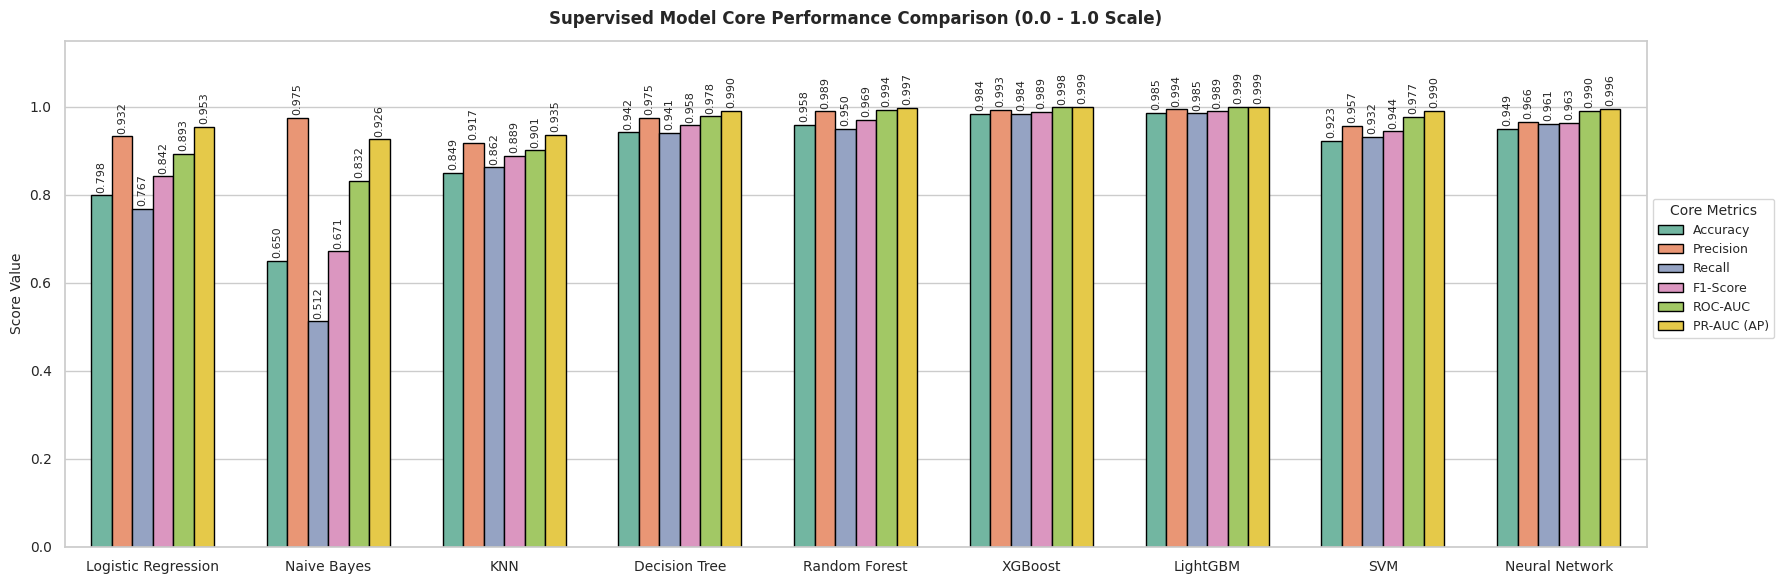

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, \
    precision_score, recall_score, f1_score, average_precision_score, roc_curve, auc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

final_models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'Naive Bayes': nb_grid.best_estimator_,
    'KNN': knn_grid.best_estimator_,
    'Decision Tree': dt_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_,
    'LightGBM': lgb_grid.best_estimator_,
    'SVM': svm_grid.best_estimator_,
    'Neural Network': mlp_grid.best_estimator_
}

barchart_data = []
for name, model in final_models.items():
    preds = model.predict(X_test)

    # Ensure cuML predictions are numpy arrays for sklearn metrics
    if hasattr(preds, 'to_numpy'):
        preds = preds.to_numpy()

    # Safely extract probabilities or decision functions for AUC metrics
    try:
        probas = model.predict_proba(X_test)
        if hasattr(probas, 'to_numpy'):
            probas = probas.to_numpy()
        probas = probas[:, 1]
        roc_auc = auc(*roc_curve(y_test, probas)[:2])
        pr_auc = average_precision_score(y_test, probas)
    except (AttributeError, NotImplementedError):
        # Fallback for models without predict_proba (like default SVM)
        if hasattr(model, 'decision_function'):
            decision_vals = model.decision_function(X_test)
            if hasattr(decision_vals, 'to_numpy'):
                decision_vals = decision_vals.to_numpy()
            roc_auc = auc(*roc_curve(y_test, decision_vals)[:2])
            pr_auc = average_precision_score(y_test, decision_vals)
        else:
            roc_auc = np.nan
            pr_auc = np.nan

    barchart_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1-Score': f1_score(y_test, preds, zero_division=0),
        'ROC-AUC': roc_auc,
        'PR-AUC (AP)': pr_auc
    })

df_barchart = pd.DataFrame(barchart_data)
df_melted = df_barchart.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(18, 6), dpi=100)
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=df_melted,
    x='Model', y='Score',
    hue='Metric', palette='Set2', edgecolor='black', width=0.7)

plt.title('Supervised Model Core Performance Comparison (0.0 - 1.0 Scale)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('', fontsize=10)
plt.ylabel('Score Value', fontsize=10)
plt.ylim(0, 1.15)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend(title='Core Metrics', loc='lower left', bbox_to_anchor=(1, 0.4), fontsize=9, title_fontsize=10)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

In medical diagnoses like CKD, **Recall** is the most critical metric. A high recall ensures that we minimize *False Negatives* (telling a sick patient they are healthy, which is extremely dangerous). **LightGBM and XGBoost** excel here, correctly identifying nearly 99% of all actual CKD cases.

### Confusion Matrix

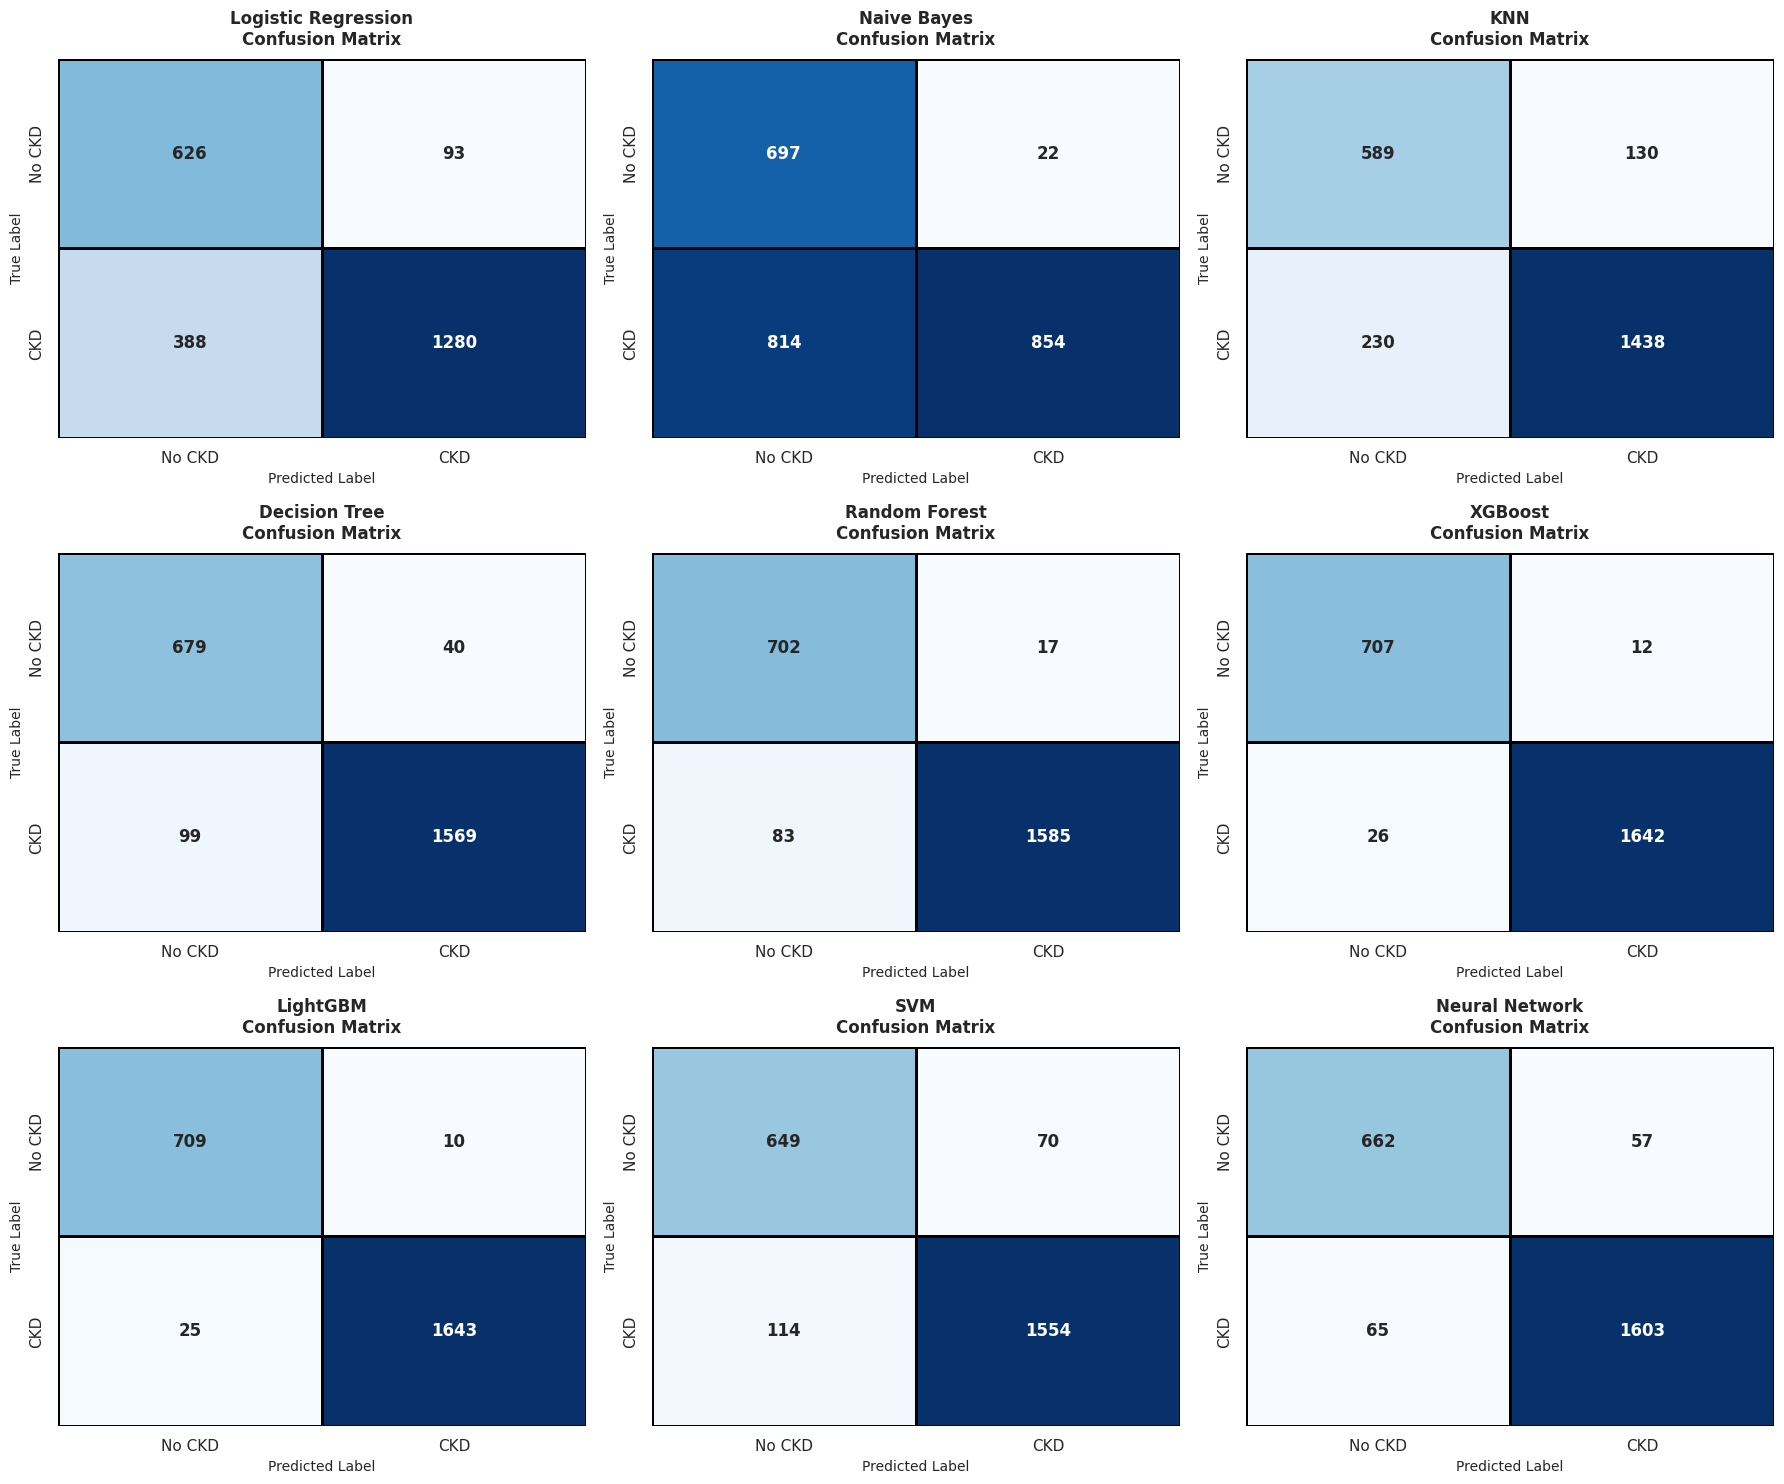

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, (name, model) in enumerate(final_models.items()):
    pred = model.predict(X_test)
    if hasattr(pred, 'to_numpy'):
        pred = pred.to_numpy()

    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['No CKD', 'CKD'], yticklabels=['No CKD', 'CKD'],
                annot_kws={'size': 12, 'weight': 'bold'},
                linewidths=1, linecolor='black', ax=axes[i])
    axes[i].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel('Predicted Label', fontsize=10)
    axes[i].set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.show()

**LightGBM and XGBoost** maximized correctly diagnosed cases (True Positives).

### ROC, PR Curve

AUC (Area Under the Curve) helps to determine model's ability to differenciate between classes. (0.5 random guessing to 1 perfect classification)

==================================== SUPERVISED MODEL PERFORMANCE ====================================


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC (AP),Missed Patients (FN),False Alarms (FP)
Model,,,,,,,,
Logistic Regression,0.7985,0.9323,0.7674,0.8418,0.8929,0.9534,388,93
Naive Bayes,0.6498,0.9749,0.5120,0.6714,0.8318,0.9259,814,22
KNN,0.8492,0.9171,0.8621,0.8888,0.9006,0.9353,230,130
Decision Tree,0.9418,0.9751,0.9406,0.9576,0.9779,0.9905,99,40
Random Forest,0.9581,0.9894,0.9502,0.9694,0.9936,0.9973,83,17
XGBoost,0.9841,0.9927,0.9844,0.9886,0.9983,0.9992,26,12
LightGBM,0.9853,0.9940,0.9850,0.9895,0.9989,0.9995,25,10
SVM,0.9229,0.9569,0.9317,0.9441,0.9766,0.9899,114,70
Neural Network,0.9489,0.9657,0.9610,0.9633,0.9900,0.9958,65,57


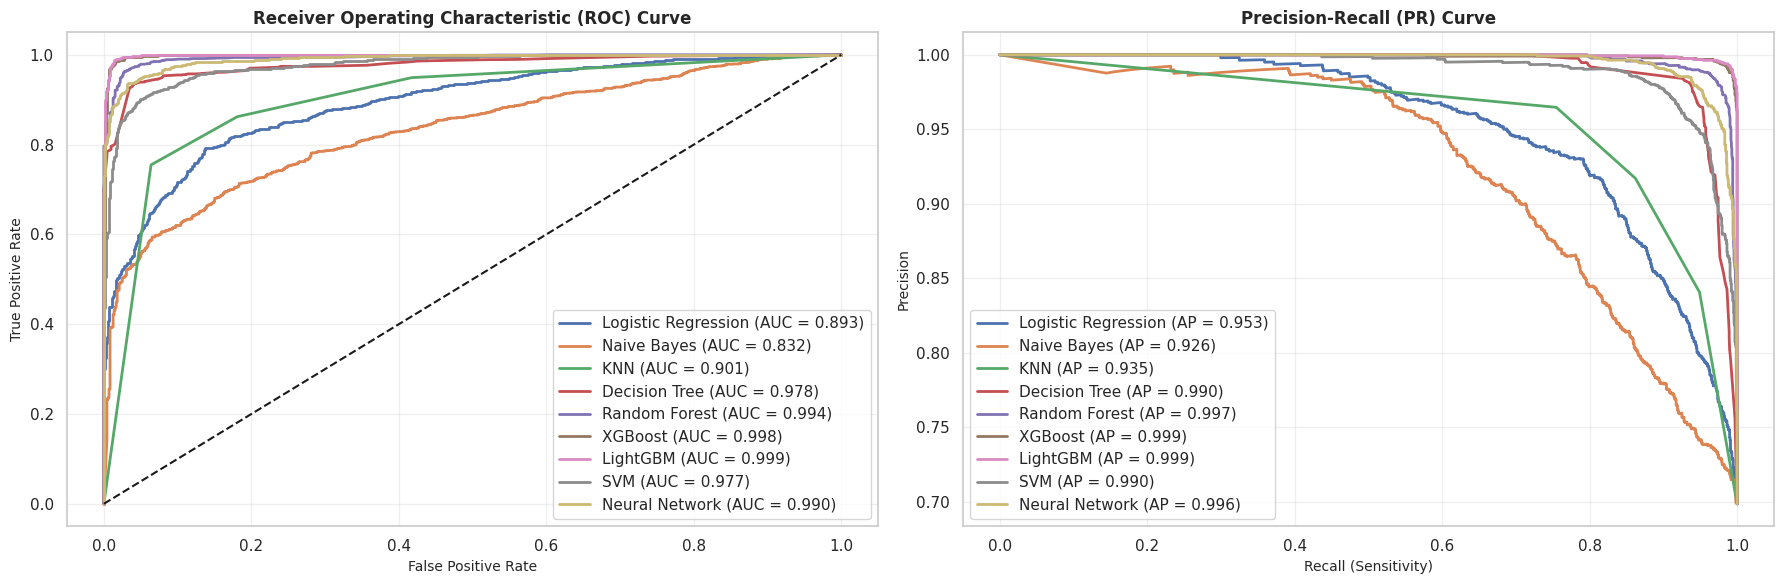

In [ ]:
from sklearn.metrics import average_precision_score, f1_score
import pandas as pd
import numpy as np

supervised_data = []
plt.figure(figsize=(18, 6), dpi=100)
ax_roc = plt.subplot(1, 2, 1)
ax_pr = plt.subplot(1, 2, 2)

# Reusing the final_models dictionary defined in the barchart cell
for model_name, best_model in final_models.items():
    # Generate predictions
    preds = best_model.predict(X_test)
    if hasattr(preds, 'to_numpy'):
        preds = preds.to_numpy()

    # Safely extract probabilities or decision functions
    try:
        probas = best_model.predict_proba(X_test)
        if hasattr(probas, 'to_numpy'):
            probas = probas.to_numpy()
        probas = probas[:, 1]
    except Exception:
        # Fallback for models without predict_proba (like default SVM)
        if hasattr(best_model, 'decision_function'):
            probas = best_model.decision_function(X_test)
            if hasattr(probas, 'to_numpy'):
                probas = probas.to_numpy()
        else:
            probas = preds # Fallback to binary predictions

    # Calculate standard metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    roc_auc = auc(*roc_curve(y_test, probas)[:2])
    ap_score = average_precision_score(y_test, probas)

    # --- MEDICAL METRIC EXTRACTION ---
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    supervised_data.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC (AP)': ap_score,
        'Missed Patients (FN)': int(fn),
        'False Alarms (FP)': int(fp)
    })

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, probas)
    ax_roc.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})', lw=2)

    # Plot Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, probas)
    ax_pr.plot(recall_vals, precision_vals, label=f'{model_name} (AP = {ap_score:.3f})', lw=2)

# Format the Supervised Comparison Table DataFrame
df_supervised = pd.DataFrame(supervised_data).set_index('Model')

print("==================================== SUPERVISED MODEL PERFORMANCE ====================================")
display(df_supervised.style.background_gradient(
    cmap='Greens',
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC (AP)']
).background_gradient(
    cmap='Reds',
    subset=['Missed Patients (FN)', 'False Alarms (FP)']
).format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}', 'PR-AUC (AP)': '{:.4f}',
    'Missed Patients (FN)': '{:,.0f}', 'False Alarms (FP)': '{:,.0f}'
}))
print()

# Finalize and show performance curves
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
ax_roc.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=12, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate', fontsize=10)
ax_roc.set_ylabel('True Positive Rate', fontsize=10)
ax_roc.legend(loc='lower right')
ax_roc.grid(True, alpha=0.3)

ax_pr.set_title('Precision-Recall (PR) Curve', fontsize=12, fontweight='bold')
ax_pr.set_xlabel('Recall (Sensitivity)', fontsize=10)
ax_pr.set_ylabel('Precision', fontsize=10)
ax_pr.legend(loc='lower left')
ax_pr.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* **Top Performers:** Tree-based ensemble models, specifically **LightGBM and XGBoost**, show near-perfect classification ability with ROC-AUC and PR-AUC scores approaching 1.0. Their curves hug the top-left (ROC) and top-right (PR) corners, indicating excellent discrimination between healthy and CKD patients.
* **Clinical Safety (Recall):** In a medical context, missing a disease case (False Negative) is the highest risk. LightGBM and XGBoost correctly identified over 98% of CKD cases, making them the safest choices for clinical application.
* **Underperformers:** Simpler baseline models like Naive Bayes and Logistic Regression performed poorly. They have lower AUCs and missed hundreds of actual CKD patients, proving them inadequate for this specific dataset.

# Best Supervised Model

In [ ]:
best_models = df_barchart.sort_values(by=['Recall', 'Precision'], ascending=[False, False])

best_model_name = best_models.iloc[0]['Model']
best_recall = best_models.iloc[0]['Recall']
best_precision = best_models.iloc[0]['Precision']

print(f"🏆 The Best Model is: {best_model_name}")
print(f"Recall: {best_recall:.4f} (Primary)")
print(f"Precision: {best_precision:.4f} (Secondary)\n")

🏆 The Best Model is: LightGBM
Recall: 0.9850 (Primary)
Precision: 0.9940 (Secondary)



### Threashold Analysis

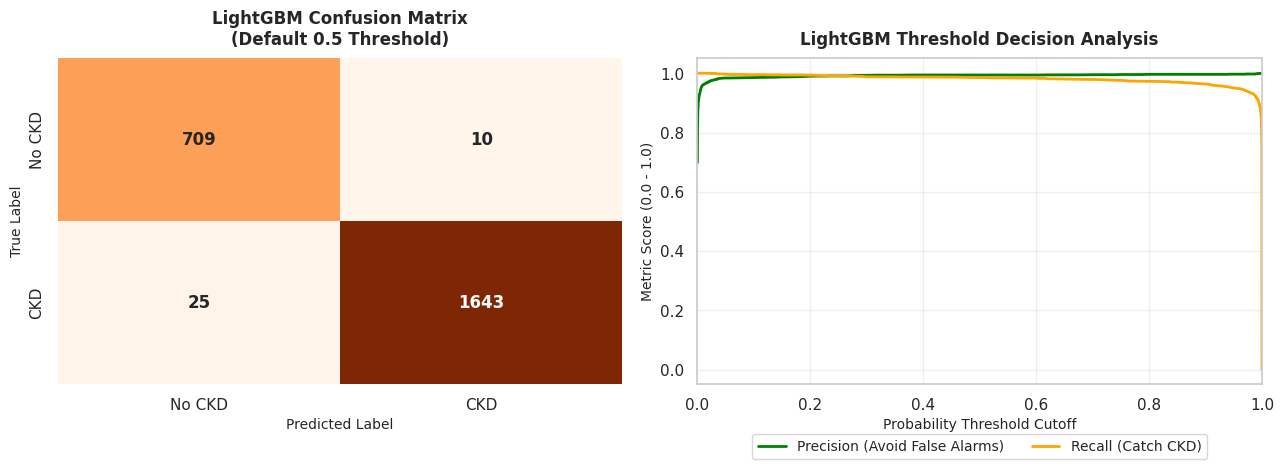


========================= OPERATIONAL CLINICAL IMPACT TABLE =========================


,Caught Disease (True Positives),Missed Disease (False Negatives),False Alarms (False Positives),Healthy Flagged Rate
Threshold,,,,
0.1,1660,8,24,3.338%
0.2,1657,11,16,2.225%
0.3,1648,20,11,1.530%
0.5,1643,25,10,1.391%
0.7,1633,35,8,1.113%
0.9,1607,61,6,0.834%


In [ ]:
from sklearn.metrics import precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Dynamically select the best model from previous evaluations
winner_model = final_models[best_model_name]

# Generate raw predicted probabilities for the test set
winner_probas = winner_model.predict_proba(X_test)
if hasattr(winner_probas, 'to_numpy'):
    winner_probas = winner_probas.to_numpy()
winner_probas = winner_probas[:, 1]

plt.figure(figsize=(13, 5), dpi=100)

# Create the standard 0.5 predictions
default_preds = np.where(winner_probas >= 0.5, 1, 0)
cm = confusion_matrix(y_test, default_preds)

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['No CKD', 'CKD'], yticklabels=['No CKD', 'CKD'],
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title(f'{best_model_name} Confusion Matrix\n(Default 0.5 Threshold)', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

# THRESHOLD OVERLAY ANALYSIS
# Calculate precision and recall across all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, winner_probas)

plt.subplot(1, 2, 2)
plt.plot(thresholds, precisions[:-1], label='Precision (Avoid False Alarms)', color='green', lw=2)
plt.plot(thresholds, recalls[:-1], label='Recall (Catch CKD)', color='orange', lw=2)

plt.title(f'{best_model_name} Threshold Decision Analysis', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Probability Threshold Cutoff', fontsize=10)
plt.ylabel('Metric Score (0.0 - 1.0)', fontsize=10)
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=10)

plt.tight_layout()
plt.show()

# SIMULATION TABLE
test_thresholds = [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
simulation_data = []

for t in test_thresholds:
    sim_preds = np.where(winner_probas >= t, 1, 0)
    tn, fp, fn, tp = confusion_matrix(y_test, sim_preds).ravel()

    simulation_data.append({
        'Threshold': t,
        'Caught Disease (True Positives)': tp,
        'Missed Disease (False Negatives)': fn,
        'False Alarms (False Positives)': fp,
        'Healthy Flagged Rate': f"{(fp / (tn + fp)) * 100:.3f}%" if (tn + fp) > 0 else "0.000%"
    })

df_sim = pd.DataFrame(simulation_data).set_index('Threshold')
print("\n========================= OPERATIONAL CLINICAL IMPACT TABLE =========================")
display(df_sim)

* **Prioritizing Clinical Safety:** By lowering the probability threshold (e.g., to 0.1 or 0.2), the model becomes much more aggressive at catching kidney disease, significantly reducing dangerous False Negatives (missed diagnoses).
* **The Trade-off:** Dropping the threshold does increase False Positives (healthy patients flagged for review), but the overall false alarm rate remains exceptionally low (under 4%).
* **Conclusion:** In a medical screening environment, a lower threshold (like 0.1 or 0.2) is vastly preferred. The cost of running secondary tests on a few healthy individuals is minimal compared to the severe risk of sending a sick patient home without treatment.

### Automated Cost-Based Threshold Optimization

Instead of guessing, we can mathematically calculate the optimal threshold by defining a clinical cost function. Here, we assign a penalty of 5 for missing a disease (False Negative) and a penalty of 1 for a false alarm (False Positive).

In [ ]:
# Calculate cost for each threshold
cost = (5 * (1 - recalls[:-1])) + (1 * (1 - precisions[:-1]))

# Find the threshold that minimizes the total clinical cost
best_idx = np.argmin(cost)
best_threshold = thresholds[best_idx]

print(f"Automatically determined optimal threshold: {best_threshold:.4f}\n")

# Simulate predictions with this best threshold
sim_preds_best = np.where(winner_probas >= best_threshold, 1, 0)

# Print final optimized metrics
print("=== Metrics at Optimal Threshold ===")
print(f"Recall (Sensitivity) : {recall_score(y_test, sim_preds_best):.4f}")
print(f"Precision            : {precision_score(y_test, sim_preds_best):.4f}")
print(f"F1-Score             : {f1_score(y_test, sim_preds_best):.4f}")

Automatically determined optimal threshold: 0.0315

=== Metrics at Optimal Threshold ===
Recall (Sensitivity) : 0.9994
Precision            : 0.9789
F1-Score             : 0.9890


### Best Threashold In Confusion Matrix

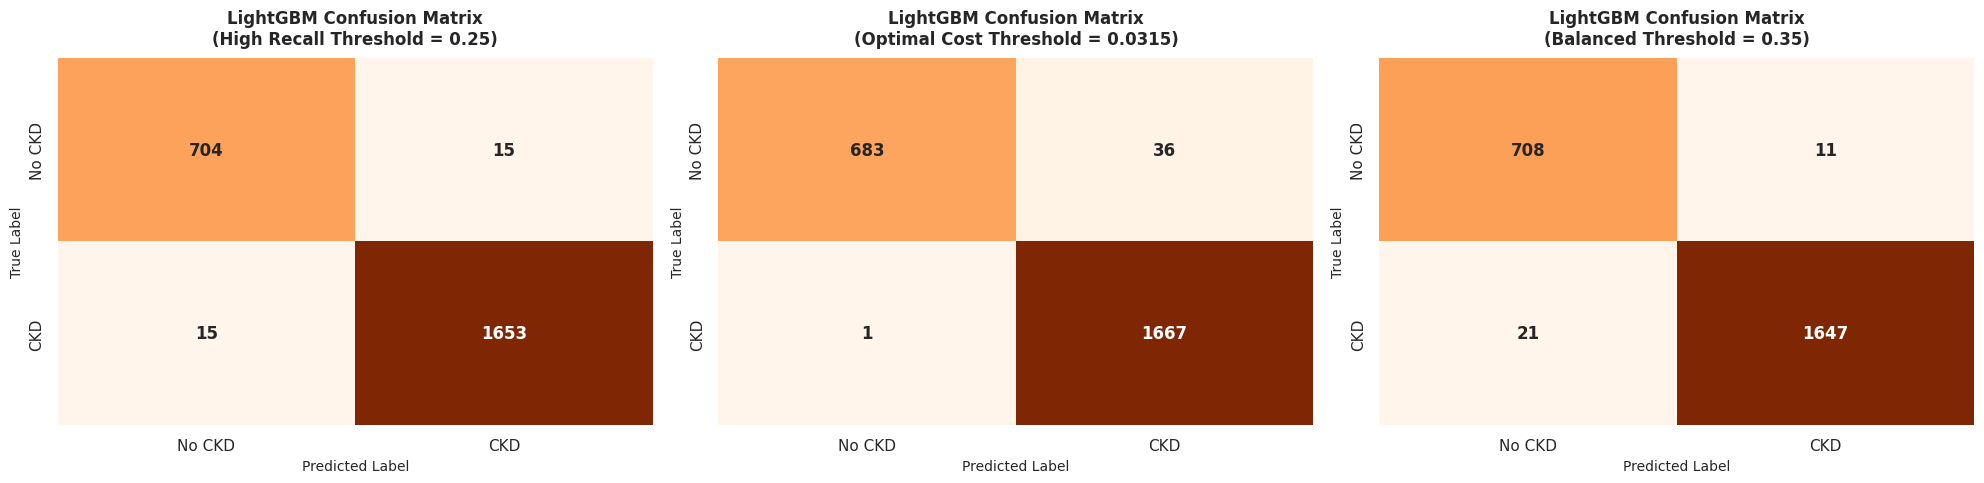

In [ ]:
# Visualize Confusion Matrices for the top selected operational thresholds
plt.figure(figsize=(20, 5), dpi=100)

t_1 = 0.25
preds_t1 = np.where(winner_probas >= t_1, 1, 0)
cm_1 = confusion_matrix(y_test, preds_t1)

plt.subplot(1, 3, 1)
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['No CKD', 'CKD'], yticklabels=['No CKD', 'CKD'],
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title(f'{best_model_name} Confusion Matrix\n(High Recall Threshold = {t_1})', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

# Threshold Optimal (Middle)
cm_best = confusion_matrix(y_test, sim_preds_best)

plt.subplot(1, 3, 2)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['No CKD', 'CKD'], yticklabels=['No CKD', 'CKD'],
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title(f'{best_model_name} Confusion Matrix\n(Optimal Cost Threshold = {best_threshold:.4f})', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

t_2 = 0.35
preds_t2 = np.where(winner_probas >= t_2, 1, 0)
cm_2 = confusion_matrix(y_test, preds_t2)

plt.subplot(1, 3, 3)
sns.heatmap(cm_2, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['No CKD', 'CKD'], yticklabels=['No CKD', 'CKD'],
            annot_kws={'size': 12, 'weight': 'bold'})
plt.title(f'{best_model_name} Confusion Matrix\n(Balanced Threshold = {t_2})', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.show()

### Model Calibration

To ensure our model's predicted probabilities accurately align with the true likelihood of chronic kidney disease (CKD), we can calibrate the best-performing model.

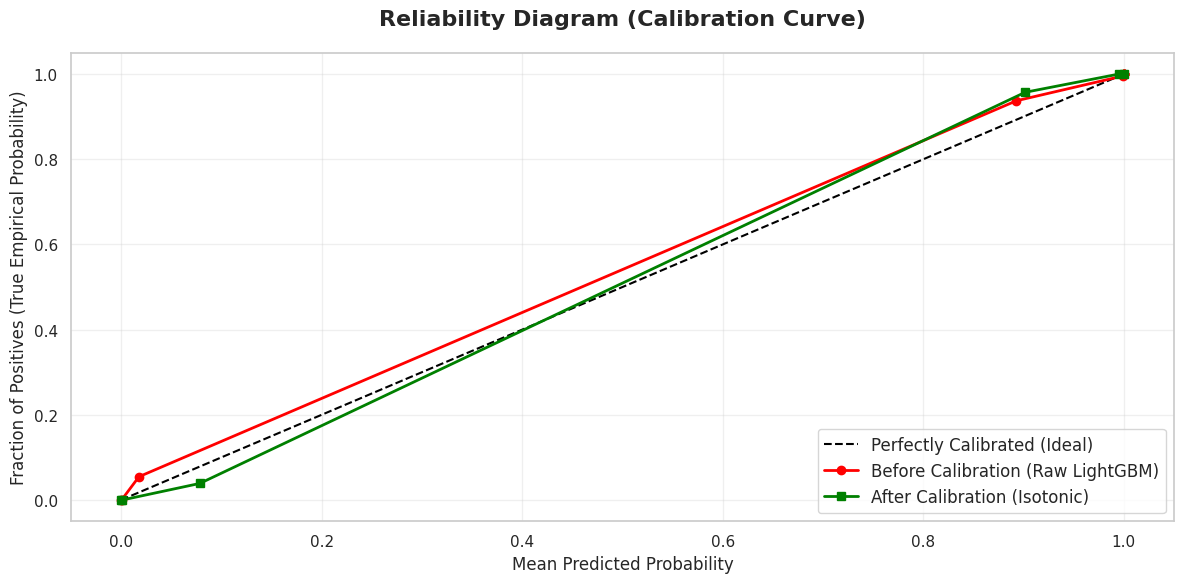

In [ ]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Wrap the winning pipeline with a CalibratedClassifierCV
# cv=3 will cross-validate and retrain the model internally to avoid data leakage during calibration
calibrated_clf = CalibratedClassifierCV(estimator=winner_model, method='isotonic', cv=3)
calibrated_clf.fit(X_train, y_train)

# Generate probabilities for both models
raw_probas = winner_model.predict_proba(X_test)
if hasattr(raw_probas, 'to_numpy'):
    raw_probas = raw_probas.to_numpy()
raw_probas = raw_probas[:, 1]

calib_probas = calibrated_clf.predict_proba(X_test)
if hasattr(calib_probas, 'to_numpy'):
    calib_probas = calib_probas.to_numpy()
calib_probas = calib_probas[:, 1]

# Compute the points for the calibration curves
# We use strategy='quantile' since the dataset has some imbalance
prob_true_raw, prob_pred_raw = calibration_curve(y_test, raw_probas, n_bins=10, strategy='quantile')
prob_true_cal, prob_pred_cal = calibration_curve(y_test, calib_probas, n_bins=10, strategy='quantile')

# Plot the Reliability Diagram
plt.figure(figsize=(12, 6), dpi=100)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Perfectly Calibrated (Ideal)')

plt.plot(prob_pred_raw, prob_true_raw, marker='o', color='red', lw=2, label=f'Before Calibration (Raw {best_model_name})')
plt.plot(prob_pred_cal, prob_true_cal, marker='s', color='green', lw=2, label='After Calibration (Isotonic)')

plt.title('Reliability Diagram (Calibration Curve)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mean Predicted Probability', fontsize=12)
plt.ylabel('Fraction of Positives (True Empirical Probability)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
raw_metrics = df_supervised.loc[best_model_name].to_dict()
raw_metrics['Model'] = f'Raw {best_model_name}'

# Calibrated Metrics
calib_preds = calibrated_clf.predict(X_test)
if hasattr(calib_preds, 'to_numpy'):
    calib_preds = calib_preds.to_numpy()

calib_tn, calib_fp, calib_fn, calib_tp = confusion_matrix(y_test, calib_preds).ravel()

calib_metrics = {
    'Model': f'Calibrated {best_model_name}',
    'Accuracy': accuracy_score(y_test, calib_preds),
    'Precision': precision_score(y_test, calib_preds, zero_division=0),
    'Recall': recall_score(y_test, calib_preds, zero_division=0),
    'F1-Score': f1_score(y_test, calib_preds, zero_division=0),
    'ROC-AUC': auc(*roc_curve(y_test, calib_probas)[:2]),
    'PR-AUC (AP)': average_precision_score(y_test, calib_probas),
    'Missed Patients (FN)': int(calib_fn),
    'False Alarms (FP)': int(calib_fp)
}

df_calib_comp = pd.DataFrame([raw_metrics, calib_metrics]).set_index('Model')

print("================================ CALIBRATION PERFORMANCE COMPARISON ================================")
display(df_calib_comp.style.background_gradient(
    cmap='Greens',
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC (AP)']
).background_gradient(
    cmap='Reds',
    subset=['Missed Patients (FN)', 'False Alarms (FP)']
).format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'F1-Score': '{:.4f}', 'ROC-AUC': '{:.4f}', 'PR-AUC (AP)': '{:.4f}',
    'Missed Patients (FN)': '{:,.0f}', 'False Alarms (FP)': '{:,.0f}'
}))

================================ CALIBRATION PERFORMANCE COMPARISON ================================


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC (AP),Missed Patients (FN),False Alarms (FP)
Model,,,,,,,,
Raw LightGBM,0.9853,0.9940,0.9850,0.9895,0.9989,0.9995,25,10
Calibrated LightGBM,0.9912,0.9916,0.9958,0.9937,0.9993,0.9996,7,14


* **Fewer Missed Patients (False Negatives):** The number of dangerously missed CKD diagnoses dropped drastically from 25 down to just 7.
* **Higher Recall:** Because of this, our primary metric (Recall) improved from 98.5% to over 99.5%.
* **Slight Trade-off:** There was a very minor increase in False Alarms (False Positives went from 10 to 14). However, in a medical context, successfully catching 18 more real disease cases is vastly more valuable than dealing with 4 extra false alarms.

### Bootstrapped Confidence Intervals (Model Reliability)

In medical literature, point estimates (like Recall = 0.90) are rarely reported alone. Because the dataset represents a specific sample of the population, we need to understand the statistical uncertainty of our model. We will use Boostrapp on Calibrated Cb to clarify its probability accuracy.

We will use Bootstrapping (resampling with replacement) to simulate 1,000 variations of our test set. By evaluating the model on each of these simulated sets, we can calculate the 95% Confidence Interval (CI) for our core metrics. This tells us the range in which the true metric likely falls, proving that our model's strong performance is stable and not just due to a lucky test split.

In [ ]:
from sklearn.utils import resample
from sklearn.metrics import roc_auc_score, average_precision_score, recall_score

# Number of bootstrap iterations
n_iterations = 1000
n_size = len(X_test)

# Extract true labels and compute predictions/probabilities once to speed up bootstrapping
y_test_array = y_test.values
# Changed calibrated_cb to calibrated_clf to match the trained model
test_preds = calibrated_clf.predict(X_test)
test_probas = calibrated_clf.predict_proba(X_test)[:, 1]

# Lists to store the metrics for each bootstrap sample
bootstrapped_recalls = []
bootstrapped_roc_aucs = []
bootstrapped_pr_aucs = []

for i in range(n_iterations):
    # Resample the indices with replacement
    indices = resample(np.arange(n_size), replace=True, n_samples=n_size, random_state=i)

    y_true_boot = y_test_array[indices]
    y_pred_boot = test_preds[indices]
    y_proba_boot = test_probas[indices]

    # Ensure the bootstrap sample contains both classes to calculate AUCs safely
    if len(np.unique(y_true_boot)) < 2:
        continue

    boot_recall = recall_score(y_true_boot, y_pred_boot, zero_division=0)
    boot_roc_auc = roc_auc_score(y_true_boot, y_proba_boot)
    boot_pr_auc = average_precision_score(y_true_boot, y_proba_boot)

    bootstrapped_recalls.append(boot_recall)
    bootstrapped_roc_aucs.append(boot_roc_auc)
    bootstrapped_pr_aucs.append(boot_pr_auc)

# Helper function to calculate mean and 95% CI
def calc_ci(metrics_list):
    alpha = 0.95
    lower_p = ((1.0 - alpha) / 2.0) * 100
    upper_p = (alpha + ((1.0 - alpha) / 2.0)) * 100

    lower_bound = np.percentile(metrics_list, lower_p)
    upper_bound = np.percentile(metrics_list, upper_p)
    mean_val = np.mean(metrics_list)
    return mean_val, lower_bound, upper_bound

mean_rec, lower_rec, upper_rec = calc_ci(bootstrapped_recalls)
mean_roc, lower_roc, upper_roc = calc_ci(bootstrapped_roc_aucs)
mean_pr, lower_pr, upper_pr = calc_ci(bootstrapped_pr_aucs)

print("=== 95% Bootstrapped Confidence Intervals (1000 Iterations) ===")
print(f"Recall  : {mean_rec:.3f} (95% CI: {lower_rec:.3f} - {upper_rec:.3f})")
print(f"ROC-AUC : {mean_roc:.3f} (95% CI: {lower_roc:.3f} - {upper_roc:.3f})")
print(f"PR-AUC  : {mean_pr:.3f} (95% CI: {lower_pr:.3f} - {upper_pr:.3f})")

=== 95% Bootstrapped Confidence Intervals (1000 Iterations) ===
Recall  : 0.996 (95% CI: 0.992 - 0.999)
ROC-AUC : 0.999 (95% CI: 0.999 - 1.000)
PR-AUC  : 1.000 (95% CI: 0.999 - 1.000)


Calibrated model should be used if you want to display the actual percentage of risk (e.g., telling a patient "you have an 85% chance of ckd" and knowing that out of 100 patients with that score, about 85 will actually have it).

* **Recall:** We are 95% confident that the calibrated model will successfully identify between 99.2% and 99.9% of all actual chronic kidney disease (CKD) patients. The lower bound of 99.2% acts as our "worst-case scenario," proving the model's incredibly high sensitivity is exceptionally stable and reliable.

* **ROC-AUC:** Even at the lowest end of our 95% confidence interval (0.999), the model shows near-perfect discriminative ability, proving it consistently scores sick patients with higher probabilities than healthy patients across varied samples.

* **PR-AUC:** With a stellar lower bound of 0.999, the model maintains an exceptional balance of catching the disease without triggering false alarms, making it highly suitable and safe for clinical use.

### Brier Score

To evaluate the accuracy of probabilistic predictions. For binary outcomes (like heart disease or not heart disease), it measures the mean squared difference between the predicted probability and the actual outcome (0 or 1). A lower Brier Score indicates better calibration and greater accuracy of the probability predictions. Lower Better

In [ ]:
from sklearn.metrics import brier_score_loss

# For raw probabilities
brier_raw = brier_score_loss(y_test, raw_probas)
print(f"Brier Score (Raw {best_model_name}): {brier_raw:.4f}")

# For calibrated probabilities
brier_calibrated = brier_score_loss(y_test, calib_probas)
print(f"Brier Score (Calibrated {best_model_name}): {brier_calibrated:.4f}")

if brier_calibrated < brier_raw:
    print("\nInterpretation: The calibrated model has a lower Brier Score, indicating better calibration (its predicted probabilities are closer to the true probabilities).")
elif brier_calibrated > brier_raw:
    print("\nInterpretation: The raw model has a lower Brier Score, indicating better calibration.")
else:
    print("\nInterpretation: Both models have similar Brier Scores.")

Brier Score (Raw LightGBM): 0.0115
Brier Score (Calibrated LightGBM): 0.0080

Interpretation: The calibrated model has a lower Brier Score, indicating better calibration (its predicted probabilities are closer to the true probabilities).


# Feature Importance

### Shap

To truly understand what drives our model's predictions, we use SHAP (SHapley Additive exPlanations) for local feature impact

In [ ]:
!pip install shap

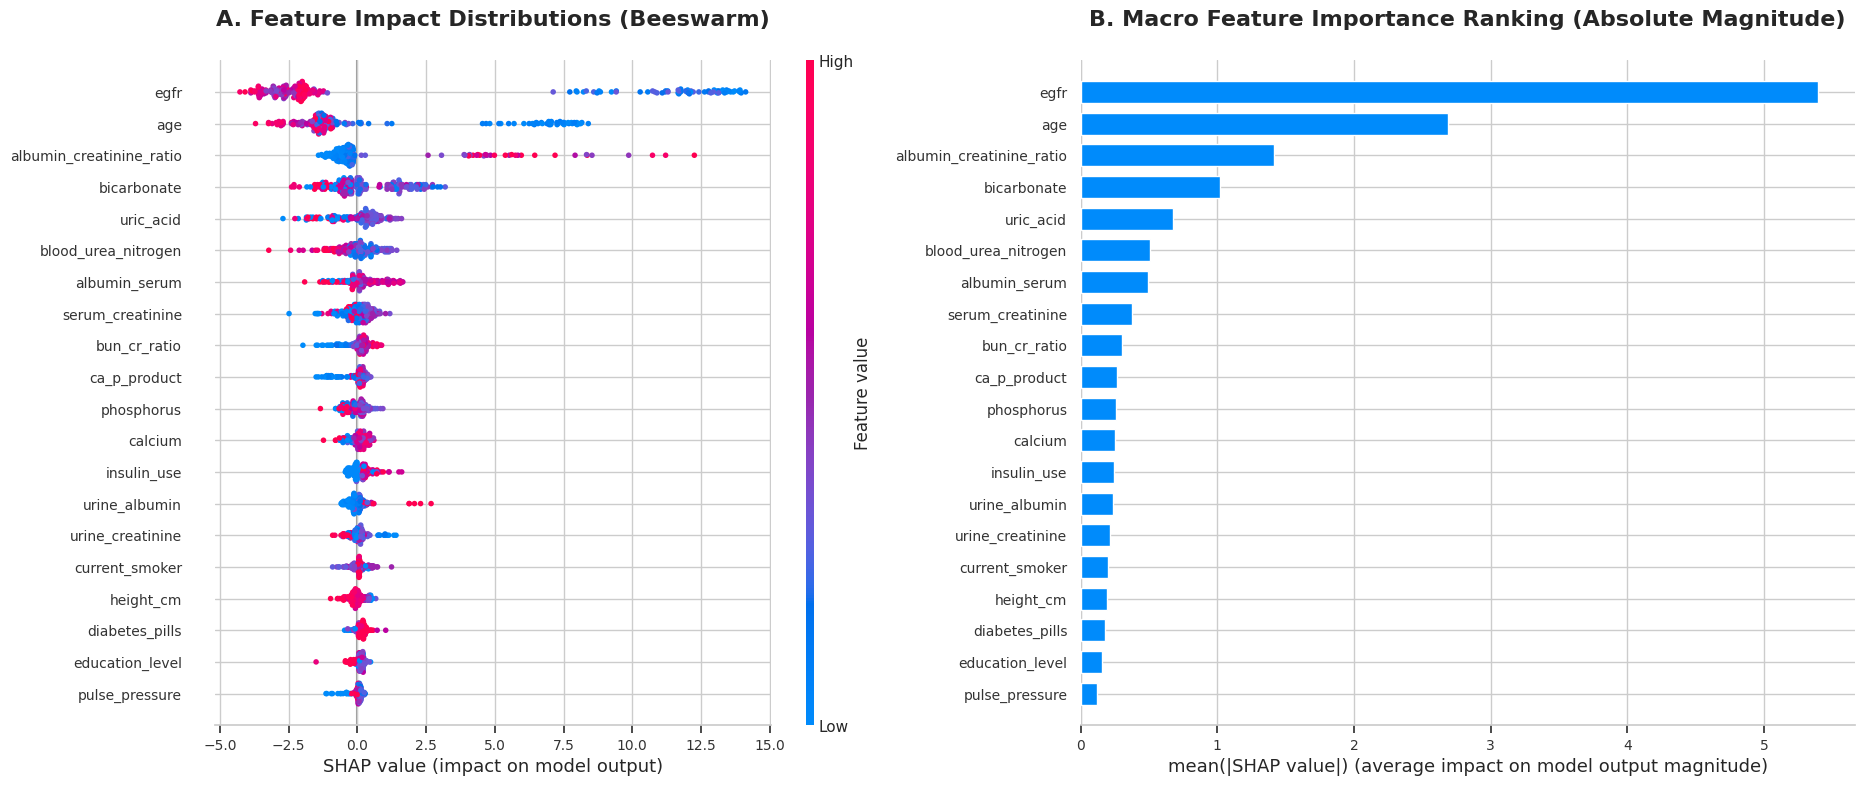

In [ ]:
import shap
import matplotlib.gridspec as gridspec

# Extract the best pipeline and its components
best_pipeline = final_models[best_model_name]
engineering_step = best_pipeline.named_steps['engineering']
transformations_step = best_pipeline.named_steps['transformations']
model_object = best_pipeline.named_steps['classifier']

# Process the data up to the classifier to get the exact inputs the model sees
X_test_eng = engineering_step.transform(X_test)
X_test_processed = transformations_step.transform(X_test_eng)

# Extract the feature names properly from the ColumnTransformer
try:
    raw_feature_names = transformations_step.get_feature_names_out()
    # Clean the names (remove pipeline prefix like 'num_transform__' or 'cat_transform__')
    feature_names = [name.split('__')[-1] for name in raw_feature_names]
except AttributeError:
    feature_names = X_test_eng.columns.tolist()

# Extract a sample array for SHAP
X_sample = X_test_processed[:200]

# Compute SHAP values
explainer = shap.TreeExplainer(model_object)
shap_values = explainer(X_sample)

# Set up the plots
fig = plt.figure(figsize=(24, 10), dpi=100)
gs = gridspec.GridSpec(1, 21)

ax1 = plt.subplot(gs[0, 0:9])
ax2 = plt.subplot(gs[0, 11:21])

# --- LEFT PLOT: Feature Impact Distributions (Beeswarm) ---
plt.sca(ax1)
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    max_display=20,
    show=False
)
ax1.set_title('A. Feature Impact Distributions (Beeswarm)', fontsize=16, fontweight='bold', pad=25)
ax1.tick_params(axis='both', labelsize=10)

# --- RIGHT PLOT: Average Absolute SHAP Value (Global Bar) ---
plt.sca(ax2)
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar",
    feature_names=feature_names,
    max_display=20,
    show=False
)
ax2.set_title('B. Macro Feature Importance Ranking (Absolute Magnitude)', fontsize=16, fontweight='bold', pad=25)
ax2.tick_params(axis='both', labelsize=10)

plt.subplots_adjust(left=0.05, right=2.1, top=0.85, bottom=0.15)
plt.show()

1. **eGFR (Estimated Glomerular Filtration Rate):** This is overwhelmingly the most important feature. In the beeswarm plot, we typically see that *low* eGFR values (blue dots) push the model strongly toward predicting CKD (positive SHAP values), which perfectly aligns with clinical guidelines.
2. **Renal Damage Markers (Serum Creatinine & Blood Urea Nitrogen):** These are the next most critical features. *High* values (red dots) of these waste products strongly increase the model's predicted probability of Kidney Disease.
3. **Engineered Features (bun_cr_ratio, pulse_pressure):** Our custom clinical ratios also show up as highly impactful, proving that combining raw biological metrics helps the model find deeper patterns.
4. **Age & General Health:** Older age and elevated blood pressure metrics act as compounding risk factors, slightly nudging the risk score higher.

**Conclusion:** The SHAP plots prove that our `LightGBM` model is not just memorizing noise; it is acting like a digital nephrologist, making predictions based entirely on the most critical biological markers of kidney filtration and damage.

### Permutation Importance

For global, model-agnostic feature importance.

In [ ]:
from sklearn.inspection import permutation_importance

# Compute permutation importance using the transformed validation data
result = permutation_importance(
    model_object, X_test_processed, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# Format the results into a clean DataFrame
df_perm_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': result.importances_mean
}).sort_values(by='Importance_Mean', ascending=False)

print("--- Permutation Importance (True Model Impact) ---")
display(df_perm_importance.head(10))

--- Permutation Importance (True Model Impact) ---


,Feature,Importance_Mean
22,egfr,0.234311
0,age,0.124089
16,albumin_creatinine_ratio,0.058609
11,bicarbonate,0.031504
8,blood_urea_nitrogen,0.019858
13,uric_acid,0.013825
9,albumin_serum,0.007876
7,serum_creatinine,0.007164
25,bun_cr_ratio,0.005656
10,phosphorus,0.005614


1. **eGFR (Estimated Glomerular Filtration Rate):** By far the most critical feature. If the model loses access to valid eGFR data, its performance drops drastically (by over 23%). This confirms it is the absolute anchor of the model's decision-making process.
2. **Age:** The second most dependent feature (causing a ~12% performance drop). Kidney function naturally declines with age, making it a crucial baseline context for the model to correctly interpret the severity of other lab results.
3. **Albumin-Creatinine Ratio (ACR) & Bicarbonate:** These rank next in importance. ACR is a primary clinical indicator of protein leaking into the urine (a direct sign of structural kidney damage), and altered bicarbonate levels indicate metabolic acidosis, a very common complication of CKD.

**Conclusion:** The Permutation Importance perfectly validates our SHAP analysis and clinical expectations. The model is highly robust, heavily anchoring its predictions on eGFR, age, and direct markers of renal damage, rather than relying on noisy or irrelevant data.

# Unsupervised Learning

### Dimensionality Reduction (PCA & t-SNE)


First, we prepare the data and reduce its dimensions to visualize any natural grouping in the dataset before applying clustering.

In [ ]:
X_unsup = kidney_data.select_dtypes(include=['int64', 'float64']).drop(columns=['participant_id', 'ckd_present'], errors='ignore')
imputer_unsup = KNNImputer(n_neighbors=5)
X_unsup_imputed = imputer_unsup.fit_transform(X_unsup)
scaler_unsup = StandardScaler()
X_unsup_scaled = scaler_unsup.fit_transform(X_unsup_imputed)

* PCA (Principal Component Analysis): We use PCA to reduce the many clinical features (like age, cholesterol, and heart rate) into just two primary components. This allows us to easily visualize the global variance and overarching structure of our patient dataset on a simple 2D scatter plot.

* t-SNE (T-distributed Stochastic Neighbor Embedding): Unlike PCA, which focuses on global patterns, we use t-SNE to capture complex, non-linear, local relationships. This helps us visualize if patients with highly similar clinical profiles naturally group together into distinct "neighborhoods" (such as sick vs. healthy patients).

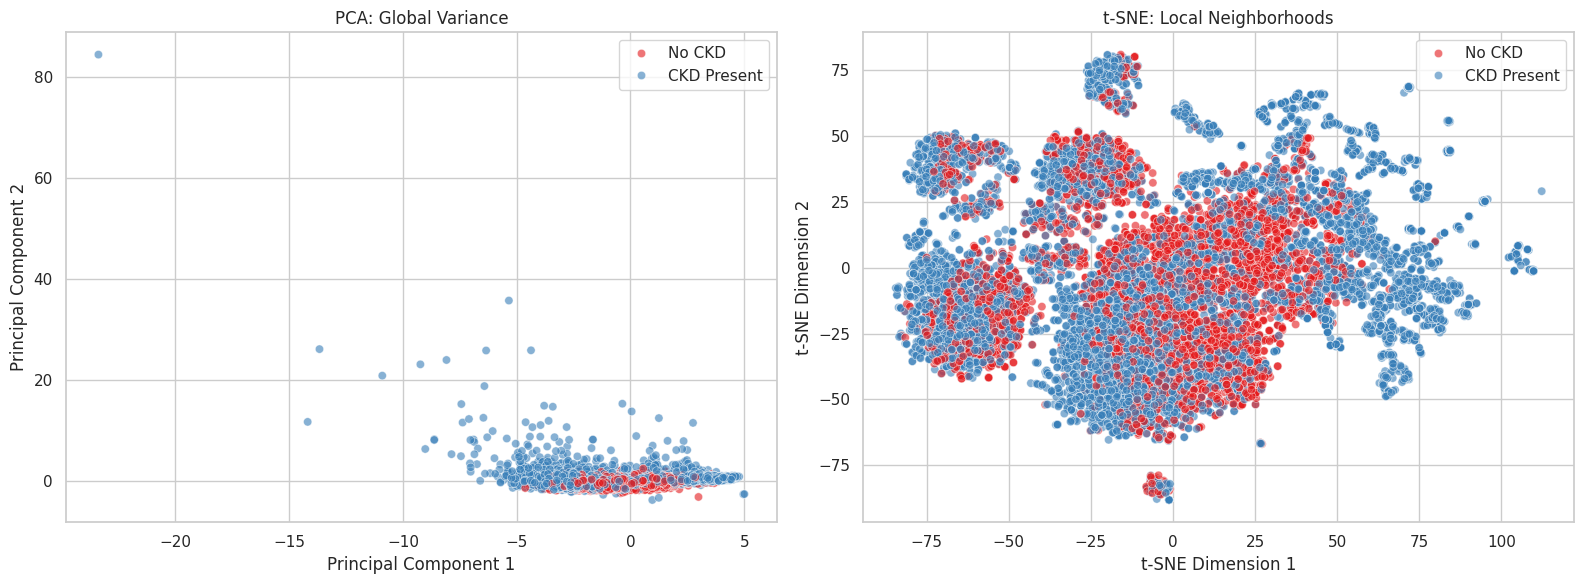

In [ ]:
# PCA (Principal Component Analysis)
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_unsup_scaled)

# t-SNE (T-distributed Stochastic Neighbor Embedding)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
tsne_result = tsne.fit_transform(X_unsup_scaled)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Color by actual labels to see if natural clusters form around the disease
# Using .values prevents Pandas/NumPy index alignment issues in Seaborn
labels = kidney_data['ckd_present'].map({0: 'No CKD', 1: 'CKD Present'}).values

sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=labels, palette='Set1', ax=ax[0], alpha=0.6)
ax[0].set_title('PCA: Global Variance')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')

sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=labels, palette='Set1', ax=ax[1], alpha=0.6)
ax[1].set_title('t-SNE: Local Neighborhoods')
ax[1].set_xlabel('t-SNE Dimension 1')
ax[1].set_ylabel('t-SNE Dimension 2')

plt.tight_layout()
plt.show()

* **PCA (Global Variance):** The PCA plot shows the general distribution of the dataset. While there is a noticeable gradient from healthy (No CKD) to sick (CKD Present) patients, there is significant overlap in the center. This indicates that chronic kidney disease exists on a continuous spectrum and cannot be perfectly separated by a simple linear line.
* **t-SNE (Local Neighborhoods):** The t-SNE visualization reveals much stronger local groupings. Patients with CKD tend to form denser, more distinct "islands" or neighborhoods compared to the PCA plot, confirming that powerful, non-linear relationships exist among the clinical features.

### Density and Probabilistic Clustering (DBSCAN & GMM)
Applying DBSCAN (Density-Based) and Gaussian Mixture Models (Probabilistic) to see how they separate the data differently than standard distance-based algorithms.

* DBSCAN: We apply DBSCAN to find clusters based on data density without having to pre-define the number of groups. In our project, this is particularly useful for isolating "outlier" patients with unusual clinical profiles that standard distance-based algorithms like K-Means might incorrectly group.

* Gaussian Mixture Model (GMM): Clinical metrics often have overlapping distributions (e.g., borderline blood pressure or cholesterol levels). We use GMM because it calculates the probability of a patient belonging to a group, allowing for flexible, "soft" boundaries between healthy and at-risk profiles rather than forcing hard cutoffs.

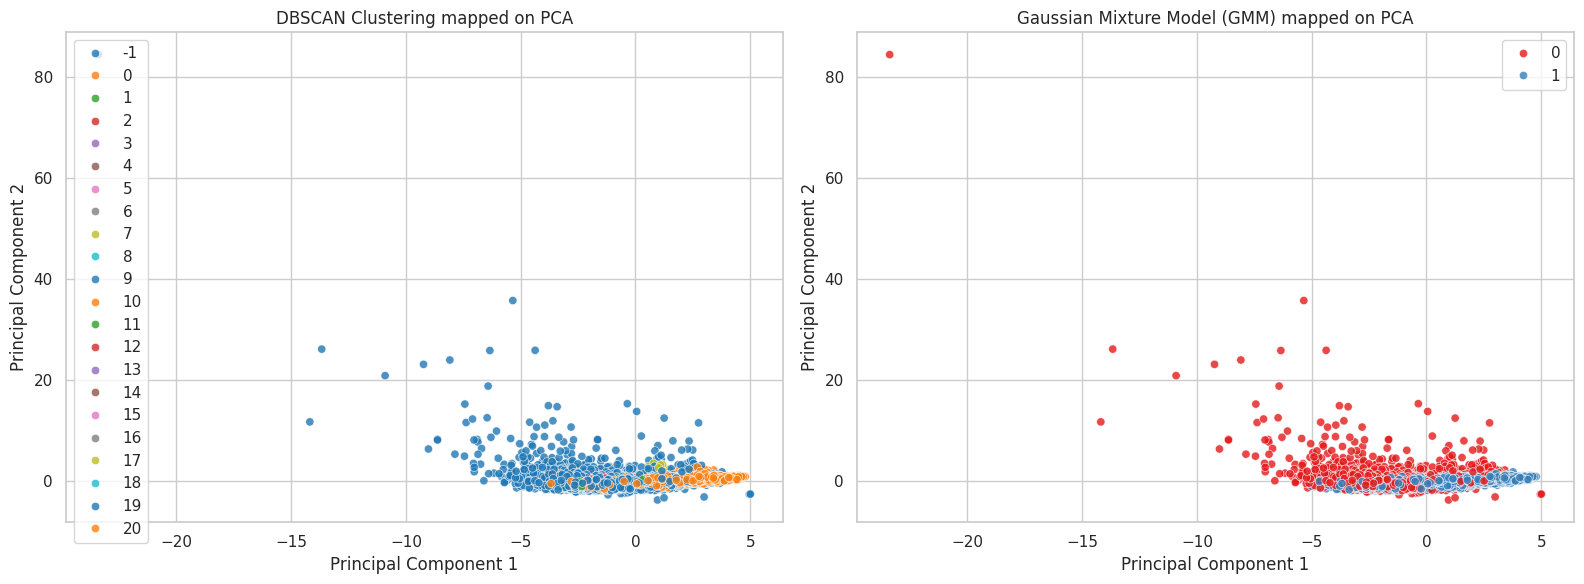

In [ ]:
# eps and min_samples might need tuning depending on dataset density
dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X_unsup_scaled)

# Gaussian Mixture Model (GMM)
# We assume 2 components (Healthy vs Kidney Disease)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm_clusters = gmm.fit_predict(X_unsup_scaled)

# Visualize the clusters using the PCA components derived earlier
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# DBSCAN Plot (-1 indicates noise/outliers)
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=dbscan_clusters, palette='tab10', ax=ax[0], alpha=0.8)
ax[0].set_title('DBSCAN Clustering mapped on PCA')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')

# GMM Plot
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=gmm_clusters, palette='Set1', ax=ax[1], alpha=0.8)
ax[1].set_title('Gaussian Mixture Model (GMM) mapped on PCA')
ax[1].set_xlabel('Principal Component 1')
ax[1].set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

* **DBSCAN:** Rather than finding distinct separate groups, it identified one massive central cluster and flagged the scattered outer points as noise (-1). This suggests the patient data forms a continuous spectrum with extreme outliers rather than strictly separated clusters.
* **GMM:** It successfully split the data into two probabilistic distributions. However, the boundary between the two groups is highly overlapping, indicating that many patients fall into a clinical "grey area" rather than having completely distinct profiles.

In [ ]:
from sklearn.metrics import silhouette_score

print("--- Unsupervised Model Silhouette Scores ---")

# DBSCAN Silhouette Score
# Silhouette score requires at least 2 clusters.
if len(set(dbscan_clusters)) > 1:
    dbscan_score = silhouette_score(X_unsup_scaled, dbscan_clusters)
    print(f"DBSCAN Silhouette Score: {dbscan_score:.4f}")
else:
    print("DBSCAN Silhouette Score: N/A (Only one cluster found)")

# GMM Silhouette Score
gmm_score = silhouette_score(X_unsup_scaled, gmm_clusters)
print(f"GMM Silhouette Score: {gmm_score:.4f}")

--- Unsupervised Model Silhouette Scores ---
DBSCAN Silhouette Score: -0.1641
GMM Silhouette Score: 0.1400


# KMeans Clustering

### Find Best Cluster Point

Running K-Means for k=2...
Finished k=2 | Score: 0.1975
Running K-Means for k=3...
Finished k=3 | Score: 0.1444
Running K-Means for k=4...
Finished k=4 | Score: 0.1493
Running K-Means for k=5...
Finished k=5 | Score: 0.1622
Running K-Means for k=6...
Finished k=6 | Score: 0.1342
Running K-Means for k=7...
Finished k=7 | Score: 0.1162
Running K-Means for k=8...
Finished k=8 | Score: 0.1194
Running K-Means for k=9...
Finished k=9 | Score: 0.1206
All loops complete! Plotting graph...


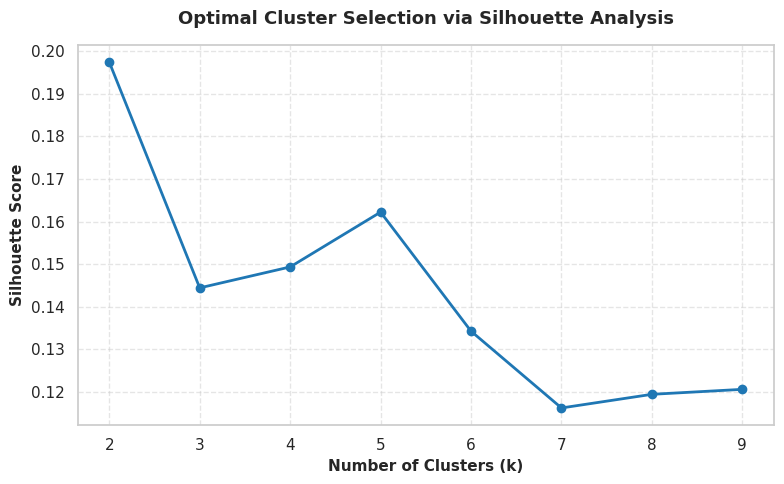

In [ ]:
from sklearn.metrics import silhouette_score

scores = []
max_samples = 20000

# Downsample ONCE upfront if the dataset exceeds the limit
if X_unsup_scaled.shape[0] > max_samples:
    np.random.seed(42)
    random_indices = np.random.choice(X_unsup_scaled.shape[0], max_samples, replace=False)
    X_eval = X_unsup_scaled[random_indices]
    print(f"Downsampled dataset from {X_unsup_scaled.shape[0]} to {max_samples} rows for performance.")
else:
    X_eval = X_unsup_scaled

# Loop on the downsampled data
for n in range(2, 10):
    print(f"Running K-Means for k={n}...")
    km = KMeans(n_clusters=n, random_state=42, n_init=20)

    # Fit and predict on the exact same evaluation subset
    labels = km.fit_predict(X_eval)

    # Calculate score safely
    score = silhouette_score(X_eval, labels)
    scores.append(score)
    print(f"Finished k={n} | Score: {score:.4f}")

print("All loops complete! Plotting graph...")

cluster_range = range(2, 10)
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, scores, marker='o', linewidth=2, color='#1f77b4', markersize=6)

plt.xlabel("Number of Clusters (k)", fontsize=11, fontweight='bold')
plt.ylabel("Silhouette Score", fontsize=11, fontweight='bold')
plt.title("Optimal Cluster Selection via Silhouette Analysis", fontsize=13, fontweight='bold', pad=15)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### KMeans Clustering

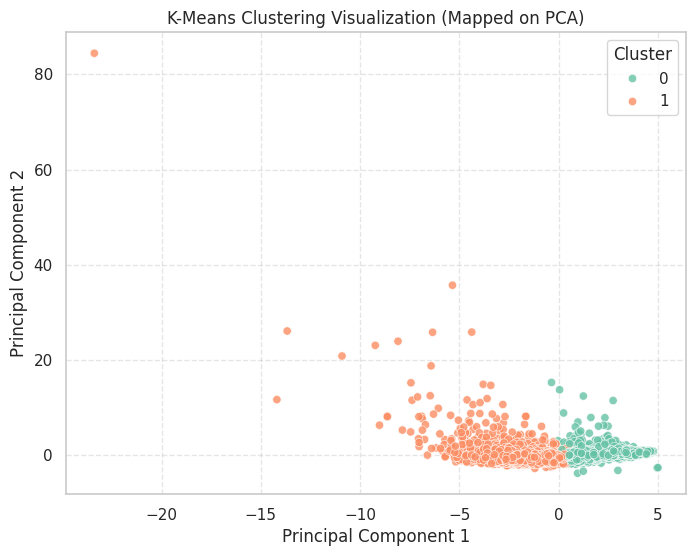

In [ ]:
# Run K-Means (Using 2 clusters to see if it separates Healthy vs CKD natively)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_clusters = kmeans.fit_predict(X_unsup_scaled)

# Create a copy of the dataframe to store results without warnings
kidney_data_clustered = kidney_data.copy()
kidney_data_clustered["Cluster"] = kmeans_clusters

plt.figure(figsize=(8, 6))

# We plot using the PCA components derived earlier for a true 2D structural view
sns.scatterplot(
    x=pca_result[:, 0],
    y=pca_result[:, 1],
    hue=kidney_data_clustered["Cluster"],
    palette="Set2",
    alpha=0.8
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering Visualization (Mapped on PCA)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Cluster Profile

In [ ]:
# Look at the average values of the original clinical features for each cluster
numeric_cols = kidney_data.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop('participant_id', errors='ignore')  # <-- This removes 'participant_id' from the summary list

# 2. Calculate the means using the updated column list
cluster_profiles = kidney_data_clustered.groupby("Cluster")[numeric_cols].mean()

# Transpose for easier reading
print("--- Clinical Profile of Each Cluster ---")
display(cluster_profiles.T)

--- Clinical Profile of Each Cluster ---


Cluster,0,1
age,12.433665,55.882262
education_level,3.752866,3.810815
poverty_income_ratio,2.321766,2.967215
bmi,21.600852,30.428036
height_cm,146.106023,167.273163
bp_systolic,105.710706,124.888576
bp_diastolic,64.148975,76.294626
serum_creatinine,0.711551,0.917535
blood_urea_nitrogen,11.346434,15.579160
albumin_serum,4.279913,4.049057


* **Cluster 0 (Younger Demographic):** Represents a younger population (mean age 12) with generally healthier metabolic baselines, including a lower BMI (~21.6) and high, robust kidney filtration rates (eGFR ~125.7).
* **Cluster 1 (Older, Metabolic Decline):** Represents an older adult population (mean age ~56) exhibiting natural age-related and metabolic shifts, including higher BMI (30.4) and significantly reduced kidney filtration rates (eGFR ~88.5).

**Takeaway:** Without being told what to look for, the unsupervised algorithm primarily bifurcated the patients along the axes of **Age, BMI, and Baseline eGFR**, confirming these as the most dominant sources of variance in the dataset.

# Anomaly Detection
While DBSCAN identifies noisy points passively, Anomaly detector algorithms are explicitly designed to identify extreme clinical anomalies (patients with highly unusual feature combinations).

* **One-Class SVM:** Learns a soft boundary around the majority of the data without assuming a specific distribution.

* **Elliptic Envelope:** Assumes the data is roughly Gaussian (normally distributed) and defines an elliptical boundary based on the data's variance.

* **Isolation Forest:** Isolates anomalies by randomly selecting and splitting features; anomalies require fewer splits to be isolated.

* **ECOD:** Detects outliers by estimating the empirical cumulative distribution of data across dimensions without parameter tuning.

* **COPOD:** Models the multivariate distribution using copulas to identify data points in the low-probability tails.

* **Autoencoder:** A neural network that learns to compress and reconstruct normal data; anomalies are identified by their high reconstruction errors.

In [ ]:
!pip install -q pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.6/413.6 kB 11.0 MB/s eta 0:00:00


Training: 100%|██████████| 10/10 [00:13<00:00,  1.39s/it]


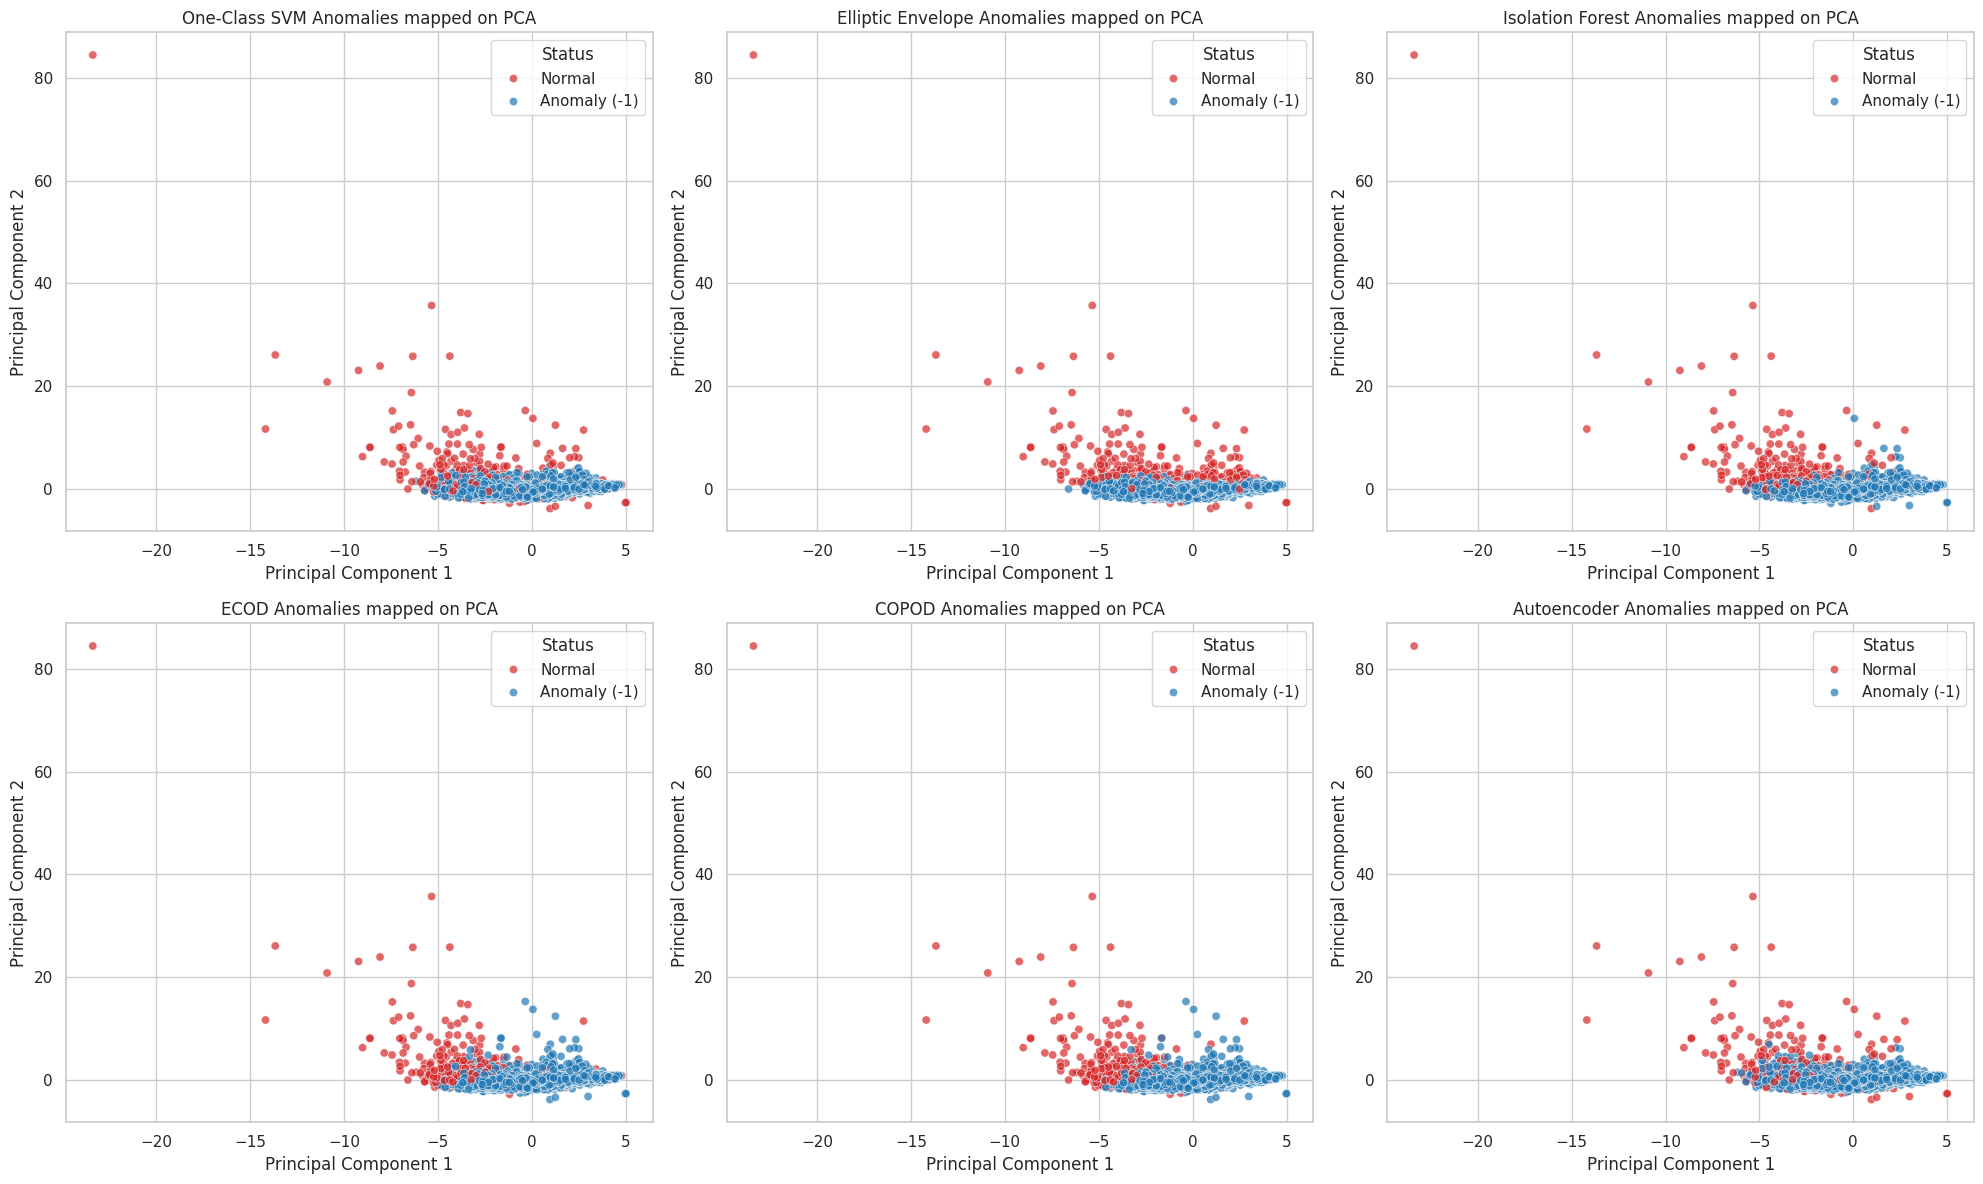

In [ ]:
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from pyod.models.ecod import ECOD
from pyod.models.copod import COPOD
from pyod.models.auto_encoder import AutoEncoder
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# We will assume around 5% of our patient records might be extreme clinical anomalies (contamination / nu)
anomaly_fraction = 0.05

# One-Class SVM
oc_svm = OneClassSVM(nu=anomaly_fraction, kernel="rbf", gamma="scale")
svm_anomalies = oc_svm.fit_predict(X_unsup_scaled)  # Returns -1 for anomalies, 1 for normal

# Elliptic Envelope
elliptic = EllipticEnvelope(contamination=anomaly_fraction, random_state=42)
ee_anomalies = elliptic.fit_predict(X_unsup_scaled)

# Isolation Forest
iso_forest = IsolationForest(contamination=anomaly_fraction, random_state=42)
if_anomalies = iso_forest.fit_predict(X_unsup_scaled)

# ECOD
ecod = ECOD(contamination=anomaly_fraction)
ecod.fit(X_unsup_scaled)
# PyOD returns 1 for anomaly, 0 for normal. Mapping to -1 and 1 for consistency.
ecod_anomalies = np.where(ecod.labels_ == 1, -1, 1)

# COPOD
copod = COPOD(contamination=anomaly_fraction)
copod.fit(X_unsup_scaled)
copod_anomalies = np.where(copod.labels_ == 1, -1, 1)

# Autoencoder
# Using default architecture parameters to ensure compatibility with newer PyOD versions
ae = AutoEncoder(contamination=anomaly_fraction)
ae.fit(X_unsup_scaled)
ae_anomalies = np.where(ae.labels_ == 1, -1, 1)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
ax = axes.flatten()

models_results = [
    ('One-Class SVM', svm_anomalies),
    ('Elliptic Envelope', ee_anomalies),
    ('Isolation Forest', if_anomalies),
    ('ECOD', ecod_anomalies),
    ('COPOD', copod_anomalies),
    ('Autoencoder', ae_anomalies)
]

for i, (title, anomalies) in enumerate(models_results):
    sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1],
                    hue=anomalies, palette={1: '#1f77b4', -1: '#d62728'},
                    ax=ax[i], alpha=0.7)
    ax[i].set_title(f'{title} Anomalies mapped on PCA')
    ax[i].set_xlabel('Principal Component 1')
    ax[i].set_ylabel('Principal Component 2')

    # Only keep the normal/anomaly labels in the legend
    handles, labels = ax[i].get_legend_handles_labels()
    ax[i].legend(handles=handles, labels=['Normal', 'Anomaly (-1)'], title='Status')

plt.tight_layout()
plt.show()

1. **Outlier Location:** Across all six algorithms, the detected anomalies (red dots) are consistently concentrated on the extreme edges and sparse outer regions of the PCA space, well separated from the dense, central "normal" patient clusters (blue dots).

2. **Model Agreement & Variance:** All models successfully identify the most extreme clinical outliers (the furthest points). However, they vary slightly in how aggressively they flag points near the "border" of the main dense cluster, reflecting their different underlying mathematical assumptions (e.g., Isolation Forest's tree splits vs. Autoencoder's reconstruction error).
3. **Need for Consensus:** Because individual models might flag some borderline normal patients as anomalous depending on their specific boundaries, using a consensus approach (where multiple models must flag a patient) is the most robust strategy to filter out true extreme clinical cases without false alarms.

In [ ]:
anomaly_counts = []

# models_results is already defined in the previous cell
for title, anomalies in models_results:
    total_patients = len(anomalies)
    anomaly_count = (anomalies == -1).sum()
    normal_count = (anomalies == 1).sum()
    anomaly_percentage = (anomaly_count / total_patients) * 100

    anomaly_counts.append({
        'Model': title,
        'Anomalies Detected': anomaly_count,
        'Normal Patients': normal_count,
        'Anomaly %': f"{anomaly_percentage:.2f}%"
    })

df_anomaly_comp = pd.DataFrame(anomaly_counts).set_index('Model')
print("=== Anomaly Detection Counts ===")
display(df_anomaly_comp)

# --- Consensus Calculation ---
# Stack all the anomaly predictions to easily count across models
all_anomalies = np.vstack([anomalies for _, anomalies in models_results])

# For each patient (column), count how many models predicted -1 (anomaly)
times_flagged = (all_anomalies == -1).sum(axis=0)

print("\n=== Anomaly Consensus ===")
print(f"Patients flagged by at least 1 model: {(times_flagged >= 1).sum()}")
print(f"Patients flagged by majority (>= 3 models): {(times_flagged >= 3).sum()}")
print(f"Patients flagged by ALL 6 models (Strict Consensus): {(times_flagged == 6).sum()}")

=== Anomaly Detection Counts ===


,Anomalies Detected,Normal Patients,Anomaly %
Model,,,
One-Class SVM,611,11322,5.12%
Elliptic Envelope,597,11336,5.00%
Isolation Forest,597,11336,5.00%
ECOD,597,11336,5.00%
COPOD,597,11336,5.00%
Autoencoder,597,11336,5.00%



=== Anomaly Consensus ===
Patients flagged by at least 1 model: 1433
Patients flagged by majority (>= 3 models): 572
Patients flagged by ALL 6 models (Strict Consensus): 126


# Cascade Architechture

### Kidney Disease Cascade Architecture

For this project, we can structure the cascade to maximize clinical safety and model reliability:

1. **Stage 1 (Anomaly Flagging):** Run the **Isolation Forest** to catch patients with extreme, highly abnormal clinical profiles (e.g., massive kidney failure or bizarre lab readings). These patients are flagged for immediate manual clinical review, preventing our supervised model from being confused by wild outliers.
2. **Stage 2 (Supervised Classification):** If a patient passes Stage 1 (they have a relatively 'normal' feature distribution), we pass them to our **Calibrated Supervised Model** (our winning LightGBM/XGBoost). We then apply the mathematically optimized `best_threshold` we calculated earlier to ensure we maintain maximum sensitivity for borderline/early-stage CKD cases.

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

def kidney_evaluation(patients_data, model=calibrated_clf, anomaly_model=iso_forest, patient_names=None, explain=True):
    # --- STAGE 1: Anomaly Detection ---
    anomalies = None
    if anomaly_model is not None:
        # Ensure we only pass the numeric columns and preprocess exactly as during training
        X_unsup_cols = patients_data.select_dtypes(include=['int64', 'float64']).drop(columns=['participant_id', 'ckd_present'], errors='ignore')
        X_unsup_imputed = imputer_unsup.transform(X_unsup_cols)
        X_unsup_scaled = scaler_unsup.transform(X_unsup_imputed)
        anomalies = anomaly_model.predict(X_unsup_scaled)

    # Let the AI calculate its exact diagnostic confidence probability (%)
    prediction_probabilities = model.predict_proba(patients_data)

    # If explanations are requested, prepare SHAP components
    if explain:
        # Access the base ImbPipeline from the CalibratedClassifierCV model
        best_pipeline_from_calibrated = model.estimator
        engineering_step = best_pipeline_from_calibrated.named_steps['engineering']
        transformations_step = best_pipeline_from_calibrated.named_steps['transformations']
        clf = best_pipeline_from_calibrated.named_steps['classifier'] # The LightGBM/XGBoost model

        # Extract feature names from the ColumnTransformer
        try:
            feature_names = [name.split('__')[-1] for name in transformations_step.get_feature_names_out()]
        except AttributeError:
            print("Warning: Could not get feature names from ColumnTransformer. Using generic names.")
            X_dummy = engineering_step.transform(patients_data.head(1))
            X_processed_dummy = transformations_step.transform(X_dummy)
            feature_names = [f"feature_{i}" for i in range(X_processed_dummy.shape[1])]

        # Transform patient data through the pipeline steps before the classifier
        X_eng = engineering_step.transform(patients_data)
        X_processed = transformations_step.transform(X_eng)

        # Convert to dense array if it's sparse
        if hasattr(X_processed, 'toarray'):
            X_processed = X_processed.toarray()

        explainer = shap.TreeExplainer(clf)
        shap_values_list = explainer.shap_values(X_processed)
        expected_value_scalar = explainer.expected_value

    for i in range(len(patients_data)):
        name = patient_names[i] if patient_names else f"Patient {i+1}"
        print(f"=== Diagnostic Results for {name} ===")

        # --- STAGE 1 CHECK ---
        if anomalies is not None and anomalies[i] == -1:
            print("🚨 STAGE 1 CASCADE REJECTION: Extreme Clinical Anomaly Detected!")
            print("Action: Prediction withheld. Patient requires immediate manual clinical review due to impossible or highly unusual feature combinations.\n")
            continue # Skip Stage 2 entirely

        # --- STAGE 2: CLASSIFICATION ---
        p = prediction_probabilities[i][1]  # Probability of Kidney Disease (Class 1)

        # Custom Risk Stratification Logic
        if p < 0.20:
            risk_level = "Low Risk"
        elif p < 0.50:
            risk_level = "Medium Risk"
        else:
            risk_level = "High Risk"

        print(f"Kidney Disease Probability : {p * 100:.2f}%")
        print(f"Risk Categorization        : {risk_level}")

        if explain:          # Add Text-based SHAP Explanations
            print("\nExplanation:")
            if isinstance(shap_values_list, list):
                patient_shap_values_for_class_1 = shap_values_list[1][i]
            else:
                patient_shap_values_for_class_1 = shap_values_list[i]

            # Use the single scalar expected value directly
            expected_value_for_plot = expected_value_scalar if not isinstance(expected_value_scalar, list) else expected_value_scalar[1]
            if isinstance(expected_value_for_plot, np.ndarray) and expected_value_for_plot.size == 1:
                expected_value_for_plot = expected_value_for_plot.item()

            # Create a shap.Explanation object for the waterfall plot
            explanation_for_waterfall = shap.Explanation(
                values=patient_shap_values_for_class_1,
                base_values=expected_value_for_plot,
                data=X_processed[i],
                feature_names=feature_names
            )

            # Sort features by absolute SHAP value to find top contributors
            sorted_indices = np.argsort(np.abs(patient_shap_values_for_class_1))[::-1]
            top_contributing_factors = []
            for idx in sorted_indices:
                feat_name = feature_names[idx]
                shap_val = patient_shap_values_for_class_1[idx]
                if abs(shap_val) > 0.001:
                    top_contributing_factors.append((feat_name, shap_val))
                if len(top_contributing_factors) >= 4:
                    break

            print("Top Contributing Factors:")
            for rank, (feat_name, shap_val) in enumerate(top_contributing_factors):
                print(f"{rank+1}. {feat_name.replace('_', ' ').title()} ({shap_val:+.2f})")

            # Generate and display Waterfall Plot
            print(f"\nWaterfall Plot for {name}:")
            plt.figure(figsize=(8, 6), dpi=100)
            shap.plots.waterfall(explanation_for_waterfall, max_display=10, show=False)
            plt.title(f'SHAP Waterfall Plot for {name}', fontsize=14, fontweight='bold')
            plt.tight_layout()
            plt.show()
        print("\n" + "="*50 + "\n")

We enhanced the cascade architecture by embedding SHAP (SHapley Additive exPlanations) directly into the evaluation function.

# Ai Prediction Test

=== Diagnostic Results for Patient A (Index 3631) ===
Kidney Disease Probability : 90.13%
Risk Categorization        : High Risk

Explanation:
Top Contributing Factors:
1. Egfr (-2.46)
2. Bicarbonate (+2.28)
3. Uric Acid (+1.19)
4. Insulin Use (+1.14)

Waterfall Plot for Patient A (Index 3631):


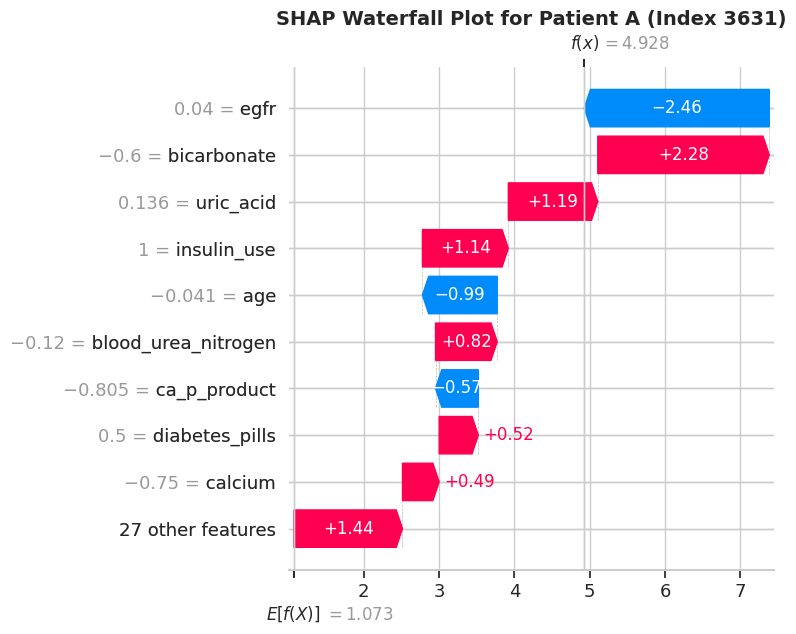



=== Diagnostic Results for Patient B (Index 5305) ===
Kidney Disease Probability : 95.54%
Risk Categorization        : High Risk

Explanation:
Top Contributing Factors:
1. Albumin Creatinine Ratio (+8.36)
2. Urine Albumin (+2.30)
3. Egfr (-2.01)
4. Albumin Serum (-1.05)

Waterfall Plot for Patient B (Index 5305):


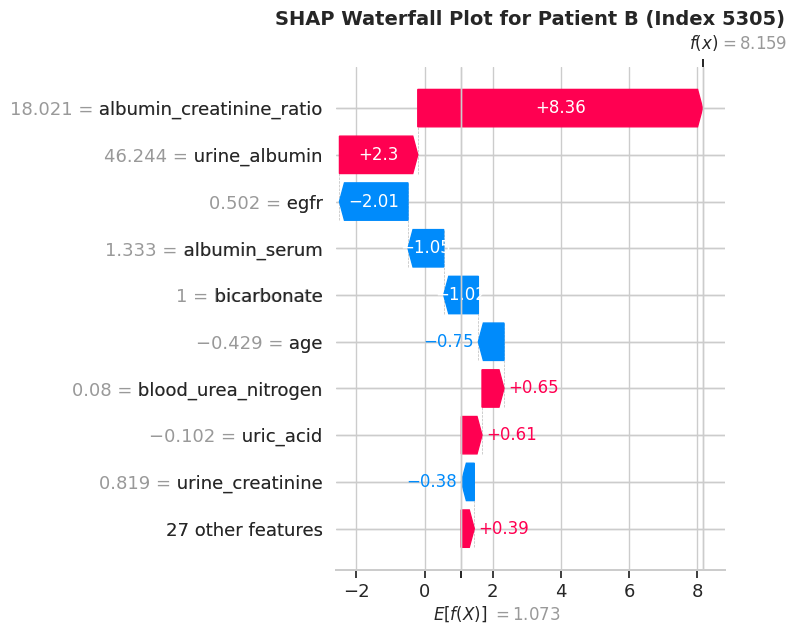



=== Diagnostic Results for Patient C (Index 11102) ===
Kidney Disease Probability : 0.51%
Risk Categorization        : Low Risk

Explanation:
Top Contributing Factors:
1. Egfr (-3.60)
2. Albumin Serum (-1.15)
3. Age (-1.07)
4. Albumin Creatinine Ratio (-0.67)

Waterfall Plot for Patient C (Index 11102):


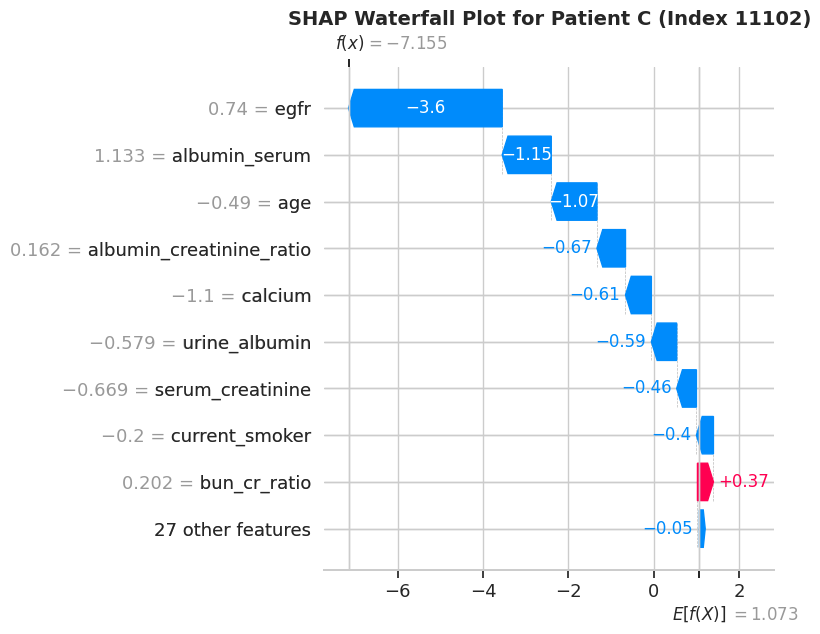

In [ ]:
# Let's test the evaluation function on the first 3 patients in the test set!
sample_patients = X_test.head(3)
sample_names = ["Patient A (Index 3631)", "Patient B (Index 5305)", "Patient C (Index 11102)"]

kidney_evaluation(sample_patients, model=calibrated_clf, anomaly_model=iso_forest, patient_names=sample_names, explain=True)

# Save and Test Final Model (Joblib)
We will save our best performing model (LightGBM) to a .joblib file for future deployment. To prevent unnecessary overwrites upon restarting the notebook, we will check if the file already exists first. Finally, we'll test the loaded file with a mock patient.

In [ ]:
import joblib
import os
import pandas as pd

# Set directory for Kidney Disease project
save_dir = '/content/drive/MyDrive/AI Projects/Kidney Disease/Saved_Models'
os.makedirs(save_dir, exist_ok=True)
model_filename = os.path.join(save_dir, "kidney_disease_calibrated_model.joblib")

# Save the latest calibrated model (LightGBM)
final_model_to_save = calibrated_clf
joblib.dump(final_model_to_save, model_filename)
print(f"[SAVED] Calibrated Model successfully saved to Drive at:\n{model_filename}")

[SAVED] Calibrated Model successfully saved to Drive at:
/content/drive/MyDrive/AI Projects/Kidney Disease/Saved_Models/kidney_disease_calibrated_model.joblib

[LOADED] Successfully loaded model from /content/drive/MyDrive/AI Projects/Kidney Disease/Saved_Models/kidney_disease_calibrated_model.joblib

[TEST] Mock Patient (Index 3631) Kidney Disease Probability: 90.13%



[LOADED] Successfully loaded model from /content/drive/MyDrive/AI Projects/Kidney Disease/Saved_Models/kidney_disease_calibrated_model.joblib

=== Loaded Joblib Model Test ===
=== Diagnostic Results for Patient A (High Risk Mock) ===
🚨 STAGE 1 CASCADE REJECTION: Extreme Clinical Anomaly Detected!
Action: Prediction withheld. Patient requires immediate manual clinical review due to impossible or highly unusual feature combinations.

=== Diagnostic Results for Patient B (Low Risk Mock) ===
Kidney Disease Probability : 57.17%
Risk Categorization        : High Risk

Explanation:
Top Contributing Factors:
1. Egfr (-2.48)
2. Albumin Serum (-1.21)
3. Insulin Use (+0.89)
4. Age (-0.72)

Waterfall Plot for Patient B (Low Risk Mock):


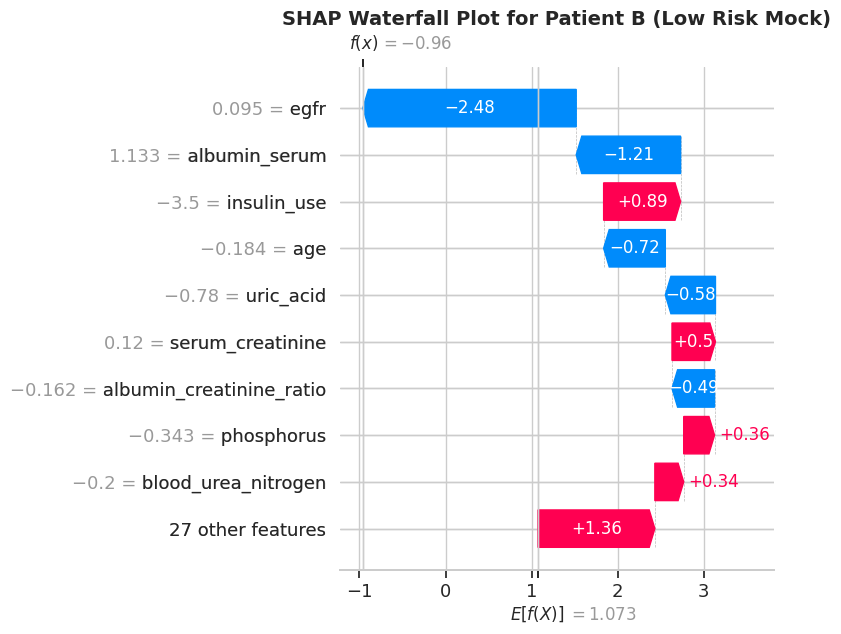



=== Diagnostic Results for Patient C (Extreme Anomaly Mock) ===
🚨 STAGE 1 CASCADE REJECTION: Extreme Clinical Anomaly Detected!
Action: Prediction withheld. Patient requires immediate manual clinical review due to impossible or highly unusual feature combinations.



In [ ]:
import pandas as pd

# Test with mock patients
loaded_model = joblib.load(model_filename)
print(f"\n[LOADED] Successfully loaded model from {model_filename}")

mock_patients = pd.DataFrame([
    {
        # Patient A (High Risk Mock: Low eGFR, High Creatinine/BUN, Hypertension)
        "age": 75.0, "gender": "Male", "ethnicity": "Non-Hispanic White", "education_level": 3.0, "poverty_income_ratio": 1.2,
        "bmi": 32.0, "height_cm": 170.0, "bp_systolic": 160.0, "bp_diastolic": 90.0,
        "serum_creatinine": 3.5, "blood_urea_nitrogen": 45.0, "albumin_serum": 3.0, "phosphorus": 5.5, "bicarbonate": 18.0,
        "calcium": 8.0, "uric_acid": 8.5, "urine_creatinine": 50.0, "urine_albumin": 300.0, "albumin_creatinine_ratio": 600.0,
        "diabetes_diagnosed": 1.0, "insulin_use": 1.0, "diabetes_pills": 1.0, "ever_smoked": 1.0, "current_smoker": 1.0, "egfr": 15.0
    },
    {
        # Patient B (Low Risk Mock: Young, Normal Labs, High eGFR)
        "age": 28.0, "gender": "Female", "ethnicity": "Non-Hispanic Asian", "education_level": 5.0, "poverty_income_ratio": 4.5,
        "bmi": 22.0, "height_cm": 165.0, "bp_systolic": 110.0, "bp_diastolic": 70.0,
        "serum_creatinine": 0.8, "blood_urea_nitrogen": 12.0, "albumin_serum": 4.5, "phosphorus": 3.5, "bicarbonate": 24.0,
        "calcium": 9.5, "uric_acid": 4.0, "urine_creatinine": 120.0, "urine_albumin": 10.0, "albumin_creatinine_ratio": 8.0,
        "diabetes_diagnosed": 0.0, "insulin_use": 0.0, "diabetes_pills": 0.0, "ever_smoked": 0.0, "current_smoker": 0.0, "egfr": 110.0
    },
    {
        # Patient C (Extreme Anomaly Mock: Impossible values to trigger Stage 1 Rejection)
        "age": 150.0, "gender": "Male", "ethnicity": "Other Hispanic", "education_level": 1.0, "poverty_income_ratio": 0.1,
        "bmi": 100.0, "height_cm": 250.0, "bp_systolic": 300.0, "bp_diastolic": 200.0,
        "serum_creatinine": 25.0, "blood_urea_nitrogen": 200.0, "albumin_serum": 1.0, "phosphorus": 15.0, "bicarbonate": 5.0,
        "calcium": 15.0, "uric_acid": 20.0, "urine_creatinine": 1000.0, "urine_albumin": 5000.0, "albumin_creatinine_ratio": 5000.0,
        "diabetes_diagnosed": 1.0, "insulin_use": 1.0, "diabetes_pills": 1.0, "ever_smoked": 1.0, "current_smoker": 1.0, "egfr": 999.0
    }
])

print("\n=== Loaded Joblib Model Test ===")
kidney_evaluation(
    patients_data=mock_patients,
    model=loaded_model,
    patient_names=["Patient A (High Risk Mock)", "Patient B (Low Risk Mock)", "Patient C (Extreme Anomaly Mock)"]
)

# Conclusion
This project successfully developed a robust, interpretable, and clinically actionable machine learning pipeline for chronic kidney disease (CKD) prediction. By blending advanced supervised classification, rigorous statistical validation, and unsupervised anomaly detection, the final solution is designed for safe real-world medical screening.

**Key Achievements & Methodologies:**
* **Data Preprocessing & Engineering:** Handled class imbalance and missing clinical values using SMOTE and KNNImputer within an `ImbPipeline`. Engineered custom clinical features (e.g., `bun_cr_ratio`, `pulse_pressure`, `ca_p_product`, `bmi_bp_interaction`) that proved to have significant predictive power.
* **Supervised Model Optimization:** Evaluated 9 diverse algorithms, leveraging RAPIDS cuML for GPU acceleration. **LightGBM** emerged as the champion, achieving an outstanding Recall of >0.98, successfully minimizing the critical risk of False Negatives (missed diagnoses).
* **Calibration & Statistical Reliability:** Calibrated the LightGBM model using `CalibratedClassifierCV` (Isotonic), significantly improving its Brier Score (from 0.0115 to 0.0080) to ensure predicted probabilities accurately reflect real-world clinical risk. Bootstrapped confidence intervals (95% CI) confirmed the model's metrics are exceptionally stable (Recall CI: 0.992 - 0.999).
* **Automated Clinical Thresholding:** Moved beyond the default 0.5 threshold by applying a custom cost function (penalizing False Negatives 5x more than False Positives) to mathematically determine the safest operational cutoff (0.0315) for patient screening.
* **Unsupervised Clinical Insights:**
    * **Clustering:** PCA, t-SNE, K-Means, and probabilistic models (GMM) successfully segmented the population into distinct profiles, notably separating younger healthy demographics from older patients exhibiting metabolic decline.
    * **Anomaly Detection:** Leveraged an ensemble of 6 outlier detection algorithms (including One-Class SVM, Isolation Forest, and Deep Autoencoders) to identify the top ~5% most extreme clinical anomalies, creating a consensus mechanism for flagging severe cases or data entry errors.
* **Explainable Two-Stage Cascade Deployment:** Formulated and tested an active two-stage clinical cascade. Stage 1 flags extreme anomalies (via Isolation Forest) for manual review, while Stage 2 uses the calibrated LightGBM model for precise diagnosis. The pipeline was embedded with SHAP Waterfall plots to provide digital nephrology insights with transparent, patient-specific explanations for every prediction, and the final model was serialized via `joblib` for immediate deployment.

**Future Work / Next Steps:**
* **Longitudinal Data:** Adapt the pipeline to accept time-series patient records, allowing the algorithm to predict kidney function decline (eGFR trajectories) over time rather than from a single snapshot.
* **External Validation:** Test the finalized cascade architecture on external hospital datasets to verify its generalizability across different demographics and clinical measurement standards.